In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def plot_training_curves(history, model_name="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    train_error = [1 - a for a in acc]
    val_error = [1 - a for a in val_acc]

    final_train_error = train_error[-1]
    final_val_error = val_error[-1]
    best_val_acc = max(val_acc)
    best_val_error = 1 - best_val_acc

    print("\n" + "=" * 60)
    print(f"EVALUARE MODEL: {model_name}")
    print("=" * 60)
    print(f"Acuratețe finală train: {acc[-1] * 100:.2f}%")
    print(f"Acuratețe finală validare: {val_acc[-1] * 100:.2f}%")
    print(f"Cea mai bună acuratețe validare: {best_val_acc * 100:.2f}%")
    print(f"Eroare finală train: {final_train_error * 100:.2f}%")
    print(f"Eroare finală validare: {final_val_error * 100:.2f}%")
    print(f"Cea mai bună estimare a erorii: {best_val_error * 100:.2f}%")

    plt.figure(figsize=(18, 10))

    # Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
    plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
    plt.title(f'Acuratețe - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Acuratețe')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, marker='o', label='Train Loss')
    plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Error evolution
    plt.subplot(2, 2, 3)
    plt.plot(epochs_range, train_error, marker='o', label='Train Error')
    plt.plot(epochs_range, val_error, marker='o', label='Validation Error')
    plt.title(f'Evoluția erorii - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Eroare = 1 - Accuracy')
    plt.legend()
    plt.grid(True)

    # Gap train-val
    gap = [abs(t - v) for t, v in zip(acc, val_acc)]
    plt.subplot(2, 2, 4)
    plt.plot(epochs_range, gap, marker='o', label='Gap |Train Acc - Val Acc|')
    plt.title(f'Estimare overfitting - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Diferență acuratețe')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import seaborn as sns

def evaluate_single_input_model(model, test_generator, model_name="Model"):
    print("\n" + "=" * 60)
    print(f"EVALUARE COMPLETĂ: {model_name}")
    print("=" * 60)

    print("\nClass indices:")
    print(test_generator.class_indices)

    # Evaluare Keras
    test_generator.reset()
    eval_results = model.evaluate(test_generator, verbose=0)

    if isinstance(eval_results, list):
        print("\nRezultate model.evaluate:")
        for name, value in zip(model.metrics_names, eval_results):
            print(f"{name}: {value:.4f}")
    else:
        print(f"\nRezultat model.evaluate: {eval_results:.4f}")

    # Predicții
    test_generator.reset()
    y_true = test_generator.classes

    y_pred_probs = model.predict(test_generator, verbose=1)

    if y_pred_probs.shape[1] == 1:
        y_pred = (y_pred_probs > 0.5).astype(int).ravel()
    else:
        y_pred = np.argmax(y_pred_probs, axis=1)

    manual_acc = np.mean(y_true == y_pred)
    print(f"\nAccuracy calculată manual: {manual_acc:.4f}")

    class_names = list(test_generator.class_indices.keys())

    print("\nRaport de clasificare:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matrice de confuzie
    cm = confusion_matrix(y_true, y_pred)

    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()

        accuracy = (tp + tn) / cm.sum()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        title = (
            f"Matrice de Confuzie - {model_name}\n"
            f"Accuracy: {accuracy:.2%} | "
            f"Sensitivity: {sensitivity:.2%} | "
            f"Specificity: {specificity:.2%}"
        )
    else:
        accuracy = np.trace(cm) / cm.sum()
        title = f"Matrice de Confuzie - {model_name}\nAccuracy: {accuracy:.2%}"

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Procent per clasă reală (%)"},
        linewidths=1,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 12, "fontweight": "bold"}
    )

    plt.title(title, fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Etichetă prezisă", fontsize=11)
    plt.ylabel("Etichetă reală", fontsize=11)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ROC pentru clasificare binară
    if y_pred_probs.shape[1] == 2:
        y_score = y_pred_probs[:, 1]

        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, linewidth=2, label=f"Curba ROC, AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Clasificator aleator")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Curba ROC - {model_name}", fontsize=13, fontweight="bold")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"AUC ROC pentru {model_name}: {roc_auc:.4f}")

# **RMN BASELINE**


100%|██████████| 361M/361M [00:02<00:00, 150MB/s]

Extracting files...


Calea catre fisiere: /root/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1
Folderul pentru antrenament MRI: /root/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1/Dataset/Brain Tumor MRI images
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Incepem antrenamentul Baseline (Intrarea 1 - RMN) ---
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 238ms/step - accuracy: 0.9320 - loss: 0.1729 - val_accuracy: 0.9580 - val_loss: 0.1056
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9720 - loss: 0.0769 - val_accuracy: 0.9690 - val_loss: 0.0781
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9835 - loss: 0.0528 - val_accuracy: 0.9700 - val_loss: 0.0752
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9845 - loss: 0.0429 - val_accuracy: 0.9740 - val_loss: 0.0724
Epoch 5

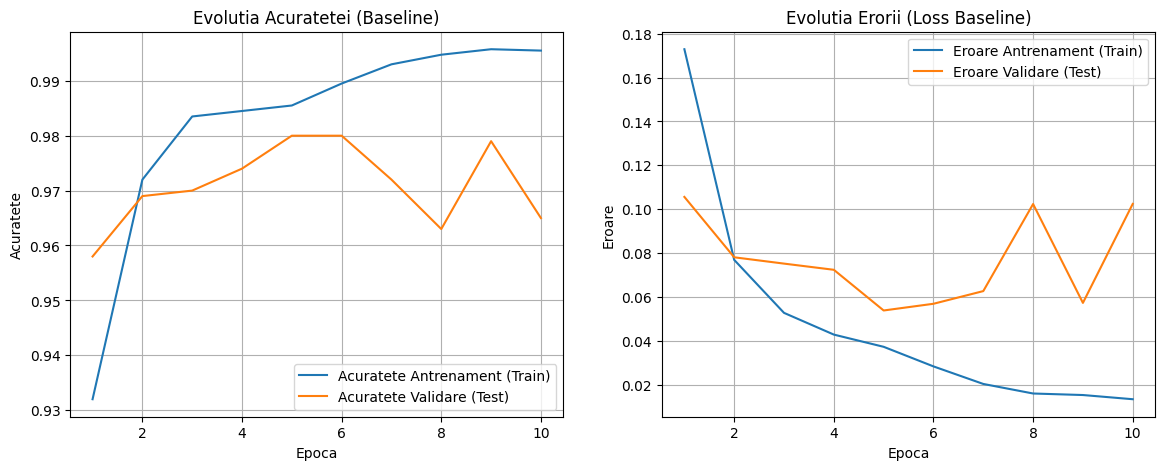

In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def plot_training_curves(history, model_name="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    train_error = [1 - a for a in acc]
    val_error = [1 - a for a in val_acc]

    final_train_error = train_error[-1]
    final_val_error = val_error[-1]
    best_val_acc = max(val_acc)
    best_val_error = 1 - best_val_acc

    print("\n" + "=" * 60)
    print(f"EVALUARE MODEL: {model_name}")
    print("=" * 60)
    print(f"Acuratețe finală train: {acc[-1] * 100:.2f}%")
    print(f"Acuratețe finală validare: {val_acc[-1] * 100:.2f}%")
    print(f"Cea mai bună acuratețe validare: {best_val_acc * 100:.2f}%")
    print(f"Eroare finală train: {final_train_error * 100:.2f}%")
    print(f"Eroare finală validare: {final_val_error * 100:.2f}%")
    print(f"Cea mai bună estimare a erorii: {best_val_error * 100:.2f}%")

    plt.figure(figsize=(18, 10))

    # Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
    plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
    plt.title(f'Acuratețe - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Acuratețe')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, marker='o', label='Train Loss')
    plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Error evolution
    plt.subplot(2, 2, 3)
    plt.plot(epochs_range, train_error, marker='o', label='Train Error')
    plt.plot(epochs_range, val_error, marker='o', label='Validation Error')
    plt.title(f'Evoluția erorii - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Eroare = 1 - Accuracy')
    plt.legend()
    plt.grid(True)

    # Gap train-val
    gap = [abs(t - v) for t, v in zip(acc, val_acc)]
    plt.subplot(2, 2, 4)
    plt.plot(epochs_range, gap, marker='o', label='Gap |Train Acc - Val Acc|')
    plt.title(f'Estimare overfitting - {model_name}')
    plt.xlabel('Epocă')
    plt.ylabel('Diferență acuratețe')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import seaborn as sns

def evaluate_single_input_model(model, test_generator, model_name="Model"):
    print("\n" + "=" * 60)
    print(f"EVALUARE COMPLETĂ: {model_name}")
    print("=" * 60)

    print("\nClass indices:")
    print(test_generator.class_indices)

    # Evaluare Keras
    test_generator.reset()
    eval_results = model.evaluate(test_generator, verbose=0)

    if isinstance(eval_results, list):
        print("\nRezultate model.evaluate:")
        for name, value in zip(model.metrics_names, eval_results):
            print(f"{name}: {value:.4f}")
    else:
        print(f"\nRezultat model.evaluate: {eval_results:.4f}")

    # Predicții
    test_generator.reset()
    y_true = test_generator.classes

    y_pred_probs = model.predict(test_generator, verbose=1)

    if y_pred_probs.shape[1] == 1:
        y_pred = (y_pred_probs > 0.5).astype(int).ravel()
    else:
        y_pred = np.argmax(y_pred_probs, axis=1)

    manual_acc = np.mean(y_true == y_pred)
    print(f"\nAccuracy calculată manual: {manual_acc:.4f}")

    class_names = list(test_generator.class_indices.keys())

    print("\nRaport de clasificare:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matrice de confuzie
    cm = confusion_matrix(y_true, y_pred)

    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()

        accuracy = (tp + tn) / cm.sum()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        title = (
            f"Matrice de Confuzie - {model_name}\n"
            f"Accuracy: {accuracy:.2%} | "
            f"Sensitivity: {sensitivity:.2%} | "
            f"Specificity: {specificity:.2%}"
        )
    else:
        accuracy = np.trace(cm) / cm.sum()
        title = f"Matrice de Confuzie - {model_name}\nAccuracy: {accuracy:.2%}"

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Procent per clasă reală (%)"},
        linewidths=1,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 12, "fontweight": "bold"}
    )

    plt.title(title, fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Etichetă prezisă", fontsize=11)
    plt.ylabel("Etichetă reală", fontsize=11)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ROC pentru clasificare binară
    if y_pred_probs.shape[1] == 2:
        y_score = y_pred_probs[:, 1]

        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, linewidth=2, label=f"Curba ROC, AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Clasificator aleator")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Curba ROC - {model_name}", fontsize=13, fontweight="bold")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"AUC ROC pentru {model_name}: {roc_auc:.4f}")
# DESCARCAREA SETULUI DE DATE
path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
print("Calea catre fisiere:", path)
#-------------------------------RMN------------------------------------------------------------------------
# Navigam exact catre folderul cu imagini RMN
base_mri_dir = os.path.join(path, "Dataset", "Brain Tumor MRI images")
print(f"Folderul pentru antrenament MRI: {base_mri_dir}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Impartim automat setul in 80% antrenament / 20% testare
datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    base_mri_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    base_mri_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# CONSTRUIREA ARHITECTURII BASELINE (Sequential)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Inghetam modelul de baza

# Construim fluxul liniar standard
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax') # 2 clase (Healthy vs. Tumor)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ANTRENAMENT
print("--- Incepem antrenamentul Baseline (Intrarea 1 - RMN) ---")
hist_mri_base = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# GRAFICE DE EVALUARE
acc = hist_mri_base.history['accuracy']
val_acc = hist_mri_base.history['val_accuracy']
loss = hist_mri_base.history['loss']
val_loss = hist_mri_base.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acuratete Antrenament (Train)')
plt.plot(epochs_range, val_acc, label='Acuratete Validare (Test)')
plt.legend(loc='lower right')
plt.title('Evolutia Acuratetei (Baseline)')
plt.xlabel('Epoca')
plt.ylabel('Acuratete')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eroare Antrenament (Train)')
plt.plot(epochs_range, val_loss, label='Eroare Validare (Test)')
plt.legend(loc='upper right')
plt.title('Evolutia Erorii (Loss Baseline)')
plt.xlabel('Epoca')
plt.ylabel('Eroare')
plt.grid(True)

plt.show()

In [ ]:
#################---------------------------------- SALVARE ACURATELE SI EROARE PENTRU UNIMODAL 1 - RMN BASELINE ---------------------------------------------------###################################
import os
import pandas as pd

RESULTS_DIR = "rezultate_modele"
os.makedirs(RESULTS_DIR, exist_ok=True)

test_generator.reset()
results = model.evaluate(test_generator, verbose=0)

loss = results[0]
accuracy = results[1]

df = pd.DataFrame([{
    "model": "mri_baseline",
    "accuracy": accuracy,
    "loss": loss
}])

fisier = os.path.join(RESULTS_DIR, "rezultate_modele.csv")

df.to_csv(
    fisier,
    mode="a",
    header=not os.path.exists(fisier),
    index=False
)

print(f"Rezultatele pentru mri_baseline au fost salvate:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss/Eroare: {loss:.4f}")

Rezultatele pentru mri_baseline au fost salvate:
Accuracy: 0.9650
Loss/Eroare: 0.1024



EVALUARE MODEL: Baseline MRI
Acuratețe finală train: 99.55%
Acuratețe finală validare: 96.50%
Cea mai bună acuratețe validare: 98.00%
Eroare finală train: 0.45%
Eroare finală validare: 3.50%
Cea mai bună estimare a erorii: 2.00%


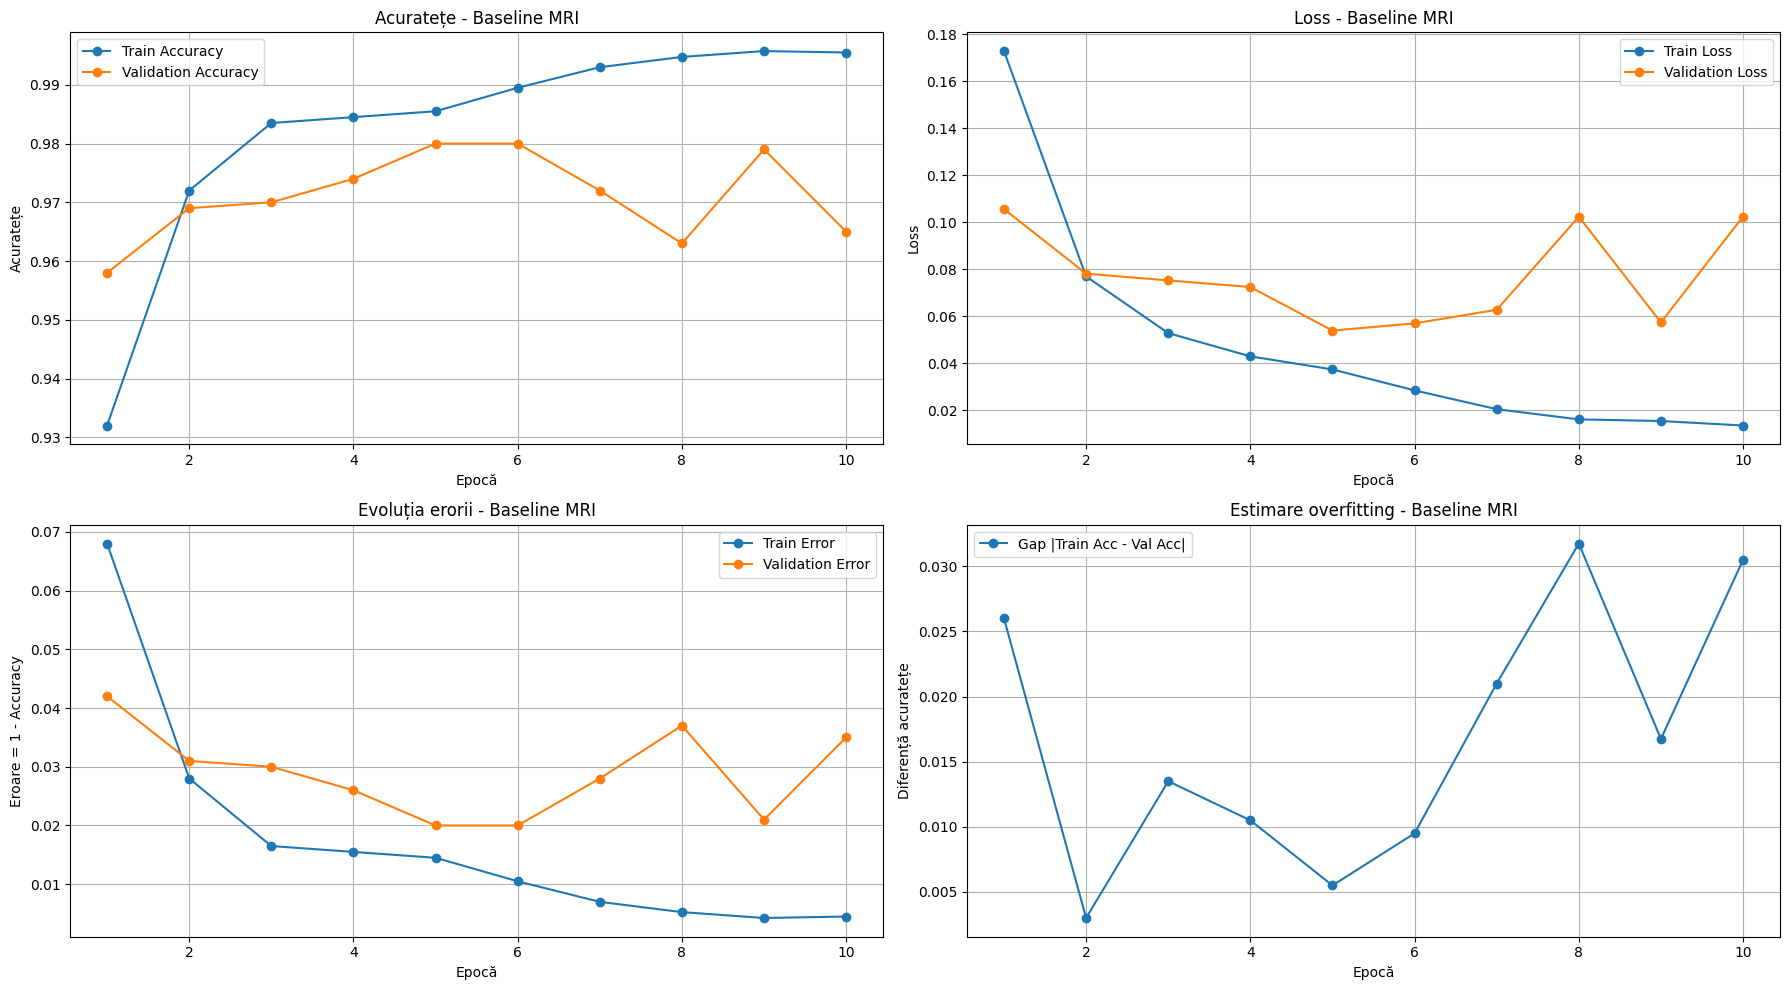

In [ ]:
plot_training_curves(hist_mri_base, "Baseline MRI")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import seaborn as sns


EVALUARE COMPLETĂ: Baseline MRI

Class indices:
{'Healthy': 0, 'Tumor': 1}

Rezultate model.evaluate:
loss: 0.1024
compile_metrics: 0.9650
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step

Accuracy calculată manual: 0.9650

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       0.98      0.93      0.96       400
       Tumor       0.95      0.99      0.97       600

    accuracy                           0.96      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.96      0.96      1000



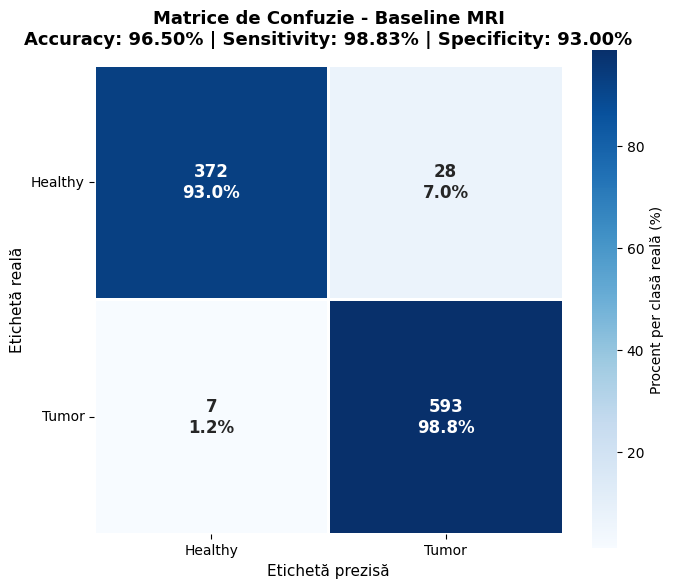

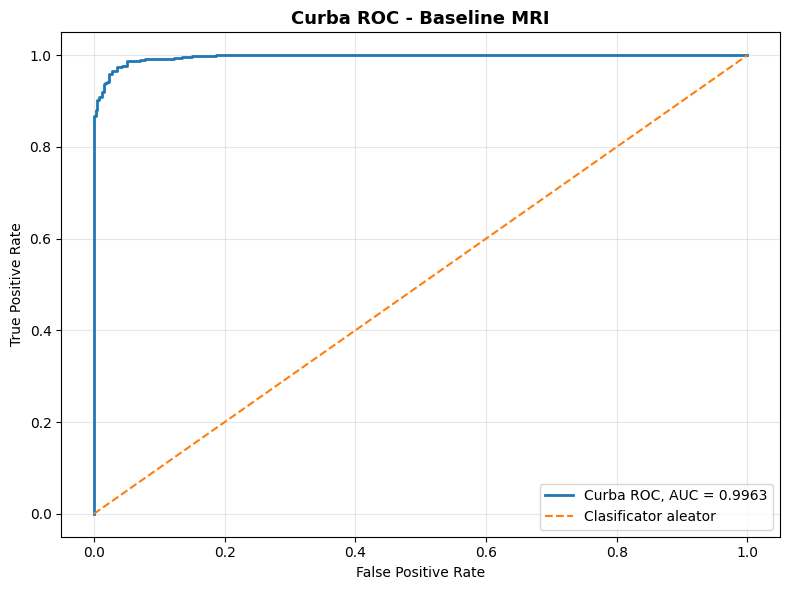

AUC ROC pentru Baseline MRI: 0.9963


In [ ]:
evaluate_single_input_model(model, test_generator, "Baseline MRI")

# **RMN FRACTIONAR SIMPLU**

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
--- Incepem antrenamentul cu Filtrul Fracționar ---
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 233ms/step - accuracy: 0.8043 - loss: 0.4137 - val_accuracy: 0.9140 - val_loss: 0.2237
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.8742 - loss: 0.2881 - val_accuracy: 0.8870 - val_loss: 0.2628
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.8960 - loss: 0.2446 - val_accuracy: 0.9500 - val_loss: 0.1405
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9003 - loss: 0.2365 - val_accuracy: 0.9460 - val_loss: 0.1556
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.9105 - loss: 0.2136 - val_accuracy: 0.9450 - val_loss: 0.1349
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9122 - loss: 0.2015 - val_accuracy: 0.9620 - v

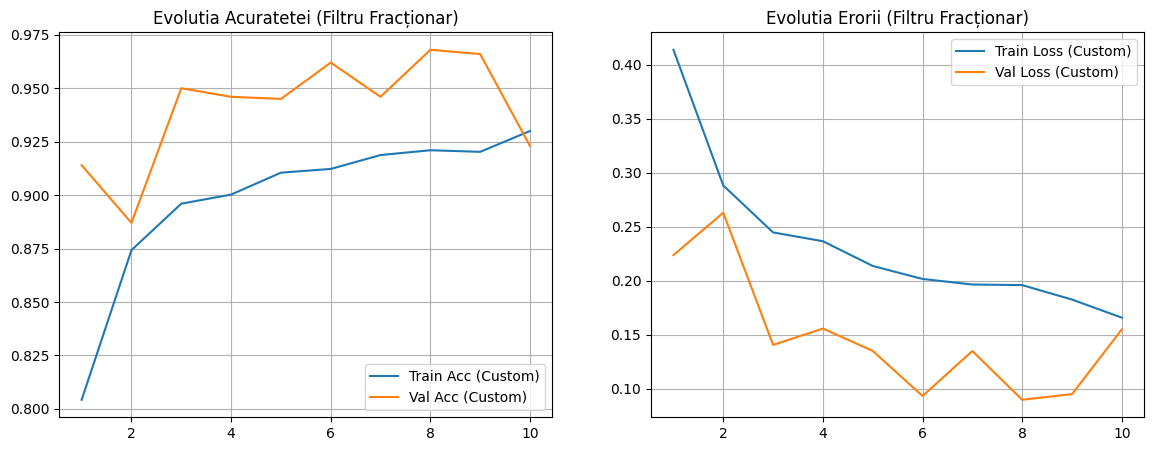

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

##------------------------------------RMN----------------------------------------------------------------

# CALEA CATRE DATE
path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
base_mri_dir = os.path.join(path, "Dataset", "Brain Tumor MRI images")

# DEFINIREA STRATULUI FRACȚIONAR
class FractionalConv2D(layers.Layer):
    def __init__(self, alpha=0.6, **kwargs):
        super(FractionalConv2D, self).__init__(**kwargs)
        self.alpha = alpha

    def build(self, input_shape):
        c0, c1, c2 = 1.0, -self.alpha, (self.alpha * (self.alpha - 1.0)) / 2.0
        mask = np.array([[c2, c1, c2], [c1, c0, c1], [c2, c1, c2]], dtype=np.float32)
        channels = input_shape[-1]
        kernel = np.zeros((3, 3, channels, 1), dtype=np.float32)
        for i in range(channels):
            kernel[:, :, i, 0] = mask
        self.kernel = tf.Variable(initial_value=kernel, trainable=False, name='fractional_kernel')

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

# PREGATIREA DATELOR (Fara rescale)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_mri_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_generator = datagen.flow_from_directory(
    base_mri_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ARHITECTURA FUNCTIONAL API CU FILTRU
input_tensor = layers.Input(shape=(224, 224, 3), name="intrare_rmn")

mapa_frac = FractionalConv2D(alpha=0.6)(input_tensor)
fuziune_intrare = layers.Add(name="fuziune_reziduala")([input_tensor, mapa_frac])

# Modelul de baza preantrenat
base_model = EfficientNetB0(weights='imagenet', include_top=False)
base_model.trainable = False

x = base_model(fuziune_intrare)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output_tensor = layers.Dense(2, activation='softmax', name="predictie_finala")(x)

# Construim modelul
model_custom = models.Model(inputs=input_tensor, outputs=output_tensor)

model_custom.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#ANTRENAMENTUL
print("--- Incepem antrenamentul cu Filtrul Fracționar ---")
history_custom = model_custom.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

#  GRAFICE DE EVALUARE
acc = history_custom.history['accuracy']
val_acc = history_custom.history['val_accuracy']
loss = history_custom.history['loss']
val_loss = history_custom.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc (Custom)')
plt.plot(epochs_range, val_acc, label='Val Acc (Custom)')
plt.legend(loc='lower right')
plt.title('Evolutia Acuratetei (Filtru Fracționar)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss (Custom)')
plt.plot(epochs_range, val_loss, label='Val Loss (Custom)')
plt.legend(loc='upper right')
plt.title('Evolutia Erorii (Filtru Fracționar)')
plt.grid(True)

plt.show()


EVALUARE MODEL: MRI cu Filtru Fracționar
Acuratețe finală train: 93.00%
Acuratețe finală validare: 92.30%
Cea mai bună acuratețe validare: 96.80%
Eroare finală train: 7.00%
Eroare finală validare: 7.70%
Cea mai bună estimare a erorii: 3.20%


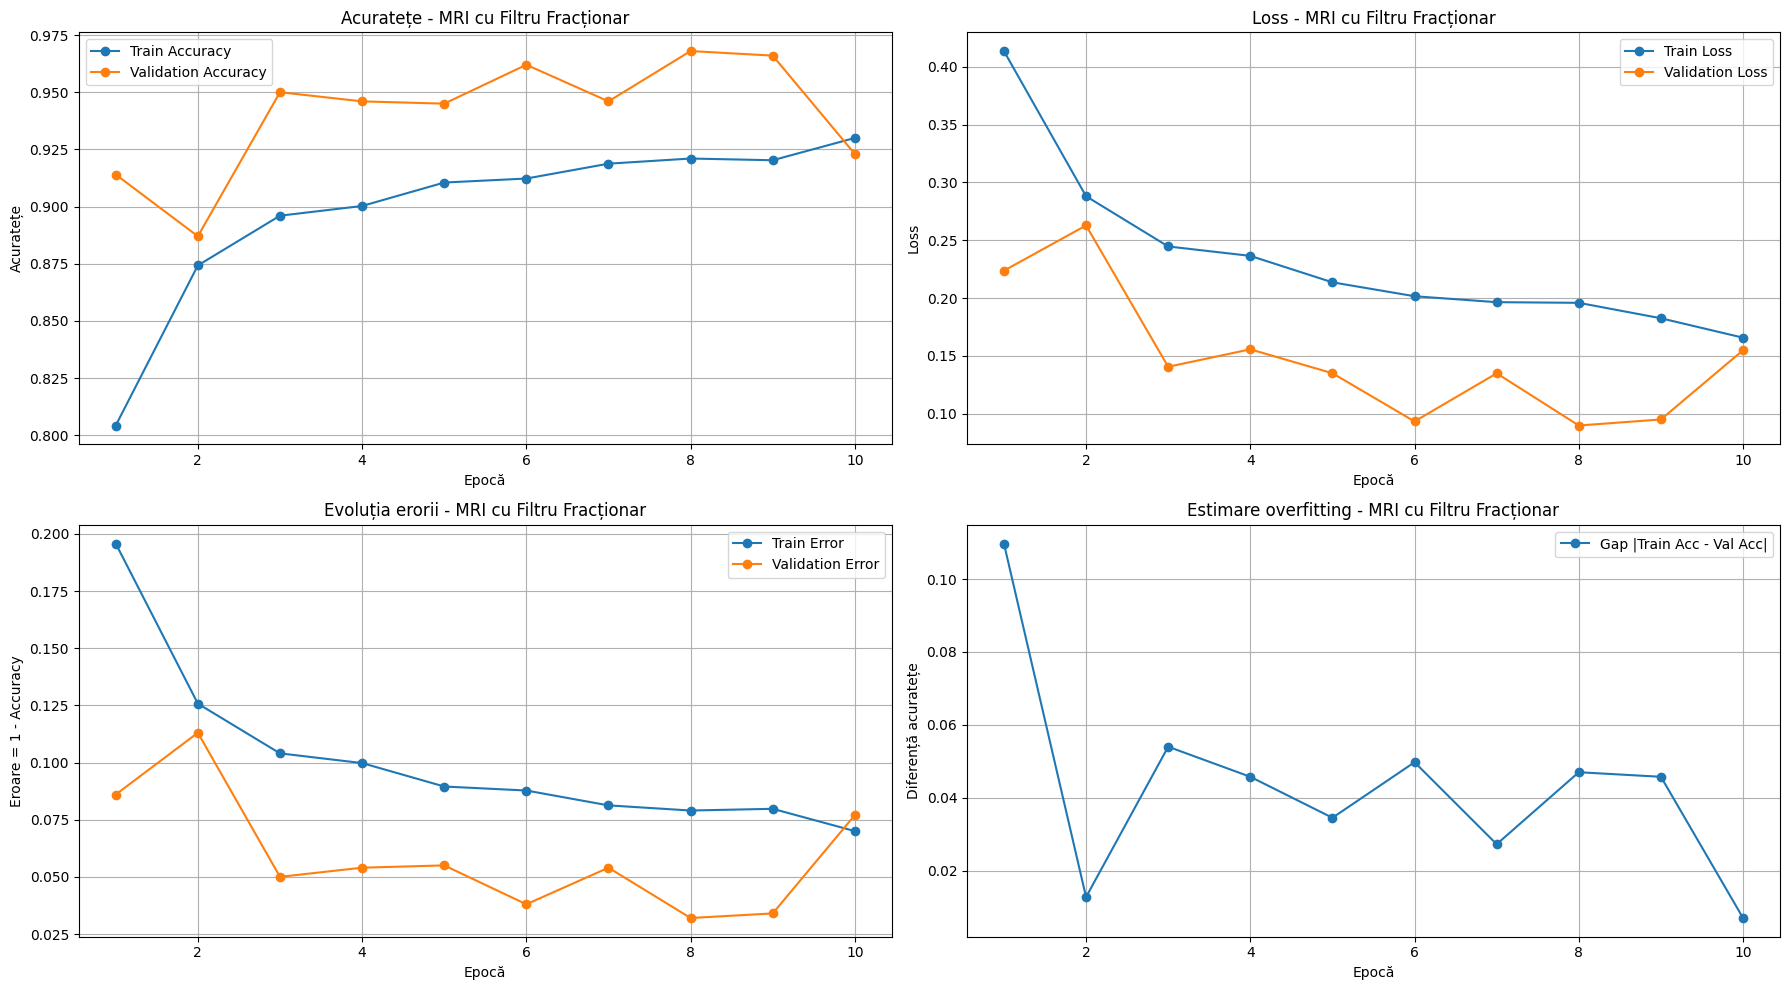

In [ ]:
plot_training_curves(history_custom, "MRI cu Filtru Fracționar")


EVALUARE COMPLETĂ: MRI cu Filtru Fracționar

Class indices:
{'Healthy': 0, 'Tumor': 1}

Rezultate model.evaluate:
loss: 0.1548
compile_metrics: 0.9230
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 333ms/step

Accuracy calculată manual: 0.9230

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       0.99      0.81      0.89       400
       Tumor       0.89      0.99      0.94       600

    accuracy                           0.92      1000
   macro avg       0.94      0.91      0.92      1000
weighted avg       0.93      0.92      0.92      1000



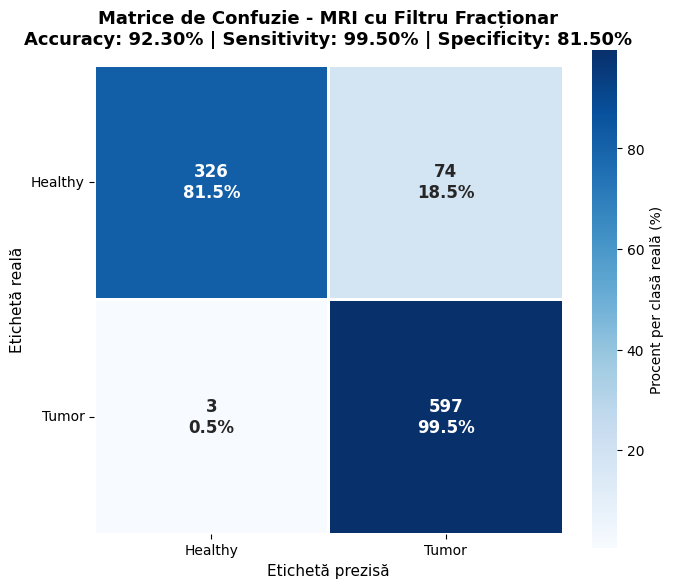

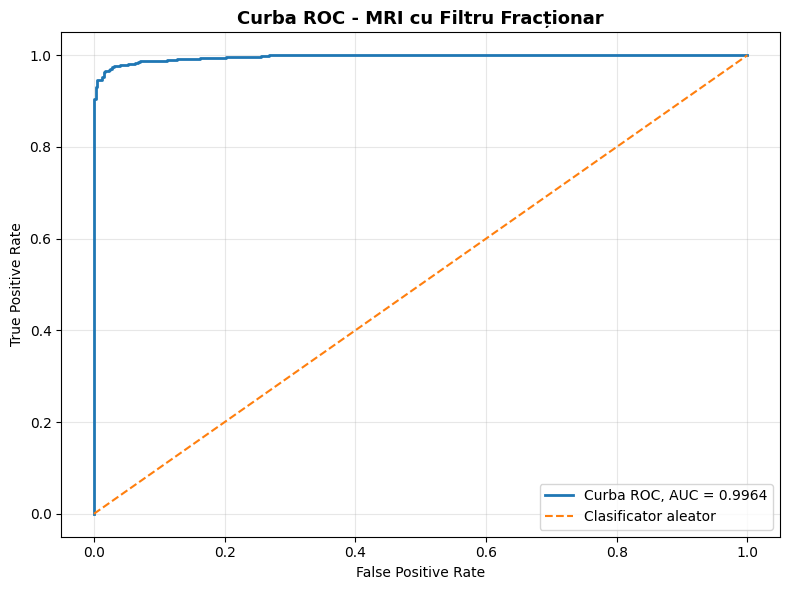

AUC ROC pentru MRI cu Filtru Fracționar: 0.9964


In [ ]:
evaluate_single_input_model(model_custom, test_generator, "MRI cu Filtru Fracționar")

In [ ]:
import os
import pandas as pd

RESULTS_DIR = "rezultate_modele"
os.makedirs(RESULTS_DIR, exist_ok=True)

test_generator.reset()
results = model_custom.evaluate(test_generator, verbose=0)

loss = results[0]
accuracy = results[1]

df = pd.DataFrame([{
    "model": "mri_fractional",
    "accuracy": accuracy,
    "loss": loss
}])

fisier = os.path.join(RESULTS_DIR, "rezultate_modele.csv")

df.to_csv(
    fisier,
    mode="a",
    header=not os.path.exists(fisier),
    index=False
)

print("Rezultatele pentru mri_fractional au fost salvate:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss/Eroare: {loss:.4f}")

Rezultatele pentru mri_fractional au fost salvate:
Accuracy: 0.9230
Loss/Eroare: 0.1548


# **RMN FRACTIONAR HIBRID**

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
--- Construim Versiunea 2.0: Modelul Fracționar Rezidual ---

--- Incepem antrenamentul modelului imbunatatit (Versiunea 2.0) ---
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 284ms/step - accuracy: 0.9302 - loss: 0.1774 - val_accuracy: 0.9390 - val_loss: 0.1508
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9712 - loss: 0.0773 - val_accuracy: 0.9680 - val_loss: 0.0884
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.9760 - loss: 0.0647 - val_accuracy: 0.9680 - val_loss: 0.0811
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9833 - loss: 0.0466 - val_accuracy: 0.9830 - val_loss: 0.0524
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9850 - val_loss: 0.0529
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━

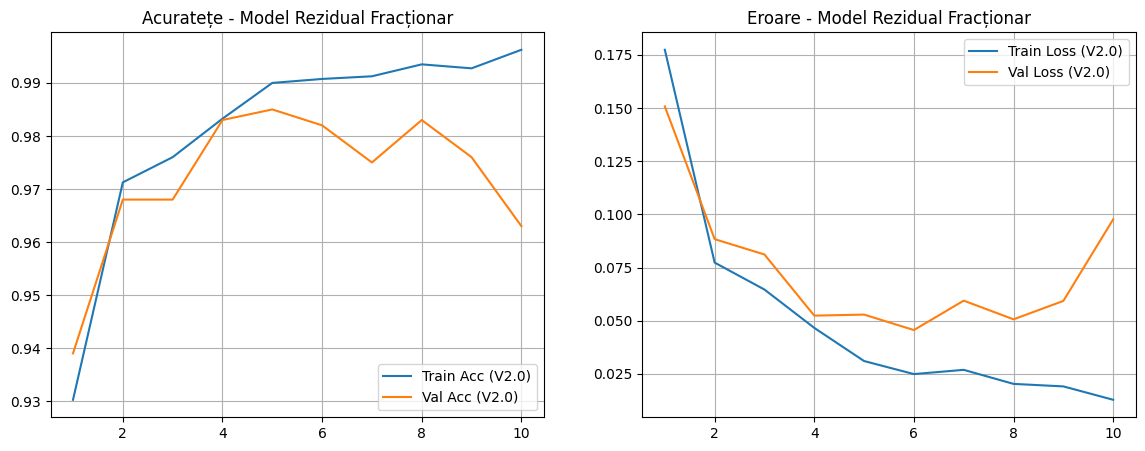

In [ ]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

##------------------------------------RMN----------------------------------------------------------------

# ---  PREGĂTIREA DATELOR  ---
path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
base_mri_dir = os.path.join(path, "Dataset", "Brain Tumor MRI images")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Fără rescale
datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_mri_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_generator = datagen.flow_from_directory(
    base_mri_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

#FRACȚIONAR ---
class FractionalConv2D(layers.Layer):
    def __init__(self, alpha=0.6, **kwargs):
        super(FractionalConv2D, self).__init__(**kwargs)
        self.alpha = alpha

    def build(self, input_shape):
        c0 = 1.0
        c1 = -self.alpha
        c2 = (self.alpha * (self.alpha - 1.0)) / 2.0
        mask = np.array([[c2, c1, c2], [c1, c0, c1], [c2, c1, c2]], dtype=np.float32)
        channels = input_shape[-1]
        kernel = np.zeros((3, 3, channels, 1), dtype=np.float32)
        for i in range(channels):
            kernel[:, :, i, 0] = mask
        self.kernel = tf.Variable(initial_value=kernel, trainable=False, name='fractional_kernel')

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

    def get_config(self):
        config = super(FractionalConv2D, self).get_config()
        config.update({'alpha': self.alpha})
        return config

# CONSTRUIRE VERSIUNEA 2: MODEL FRACȚIONAR REZIDUAL ---
print("--- Construim Versiunea 2.0: Modelul Fracționar Rezidual ---")

base_model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# DEFINIM INTRAREA
inputs = Input(shape=(224, 224, 3), name="imagine_rmn_intrare")

# DRUMUL 1: Lentila Fracționară
x_fractionar = FractionalConv2D(alpha=0.6)(inputs)
x_fractionar = layers.BatchNormalization(name="normalizare_fractionara")(x_fractionar)

# DRUMUL 2 + CONEXIUNEA REZIDUALĂ
x_combinat = layers.Add(name="conexiune_reziduala")([inputs, x_fractionar])

# EfficientNet
x = base_model(x_combinat, training=False)
x = layers.GlobalAveragePooling2D(name="aplatizare")(x)
x = layers.Dense(128, activation='relu', name="rationament_128")(x)
x = layers.Dropout(0.3, name="preventie_toceala")(x)
# Modificat pentru 2 clase
outputs = layers.Dense(2, activation='softmax', name="decizie_finala_2_clase")(x)

model_rezidual = models.Model(inputs=inputs, outputs=outputs, name="Model_Fractionar_Rezidual")

model_rezidual.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ANTRENAMENT
print("\n--- Incepem antrenamentul modelului imbunatatit (Versiunea 2.0) ---")
history_rezidual = model_rezidual.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

#GRAFICE
acc = history_rezidual.history['accuracy']
val_acc = history_rezidual.history['val_accuracy']
loss = history_rezidual.history['loss']
val_loss = history_rezidual.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc (V2.0)')
plt.plot(epochs_range, val_acc, label='Val Acc (V2.0)')
plt.legend(loc='lower right')
plt.title('Acuratețe - Model Rezidual Fracționar')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss (V2.0)')
plt.plot(epochs_range, val_loss, label='Val Loss (V2.0)')
plt.legend(loc='upper right')
plt.title('Eroare - Model Rezidual Fracționar')
plt.grid(True)
plt.show()


EVALUARE MODEL: MRI Fracționar Rezidual
Acuratețe finală train: 99.62%
Acuratețe finală validare: 96.30%
Cea mai bună acuratețe validare: 98.50%
Eroare finală train: 0.38%
Eroare finală validare: 3.70%
Cea mai bună estimare a erorii: 1.50%


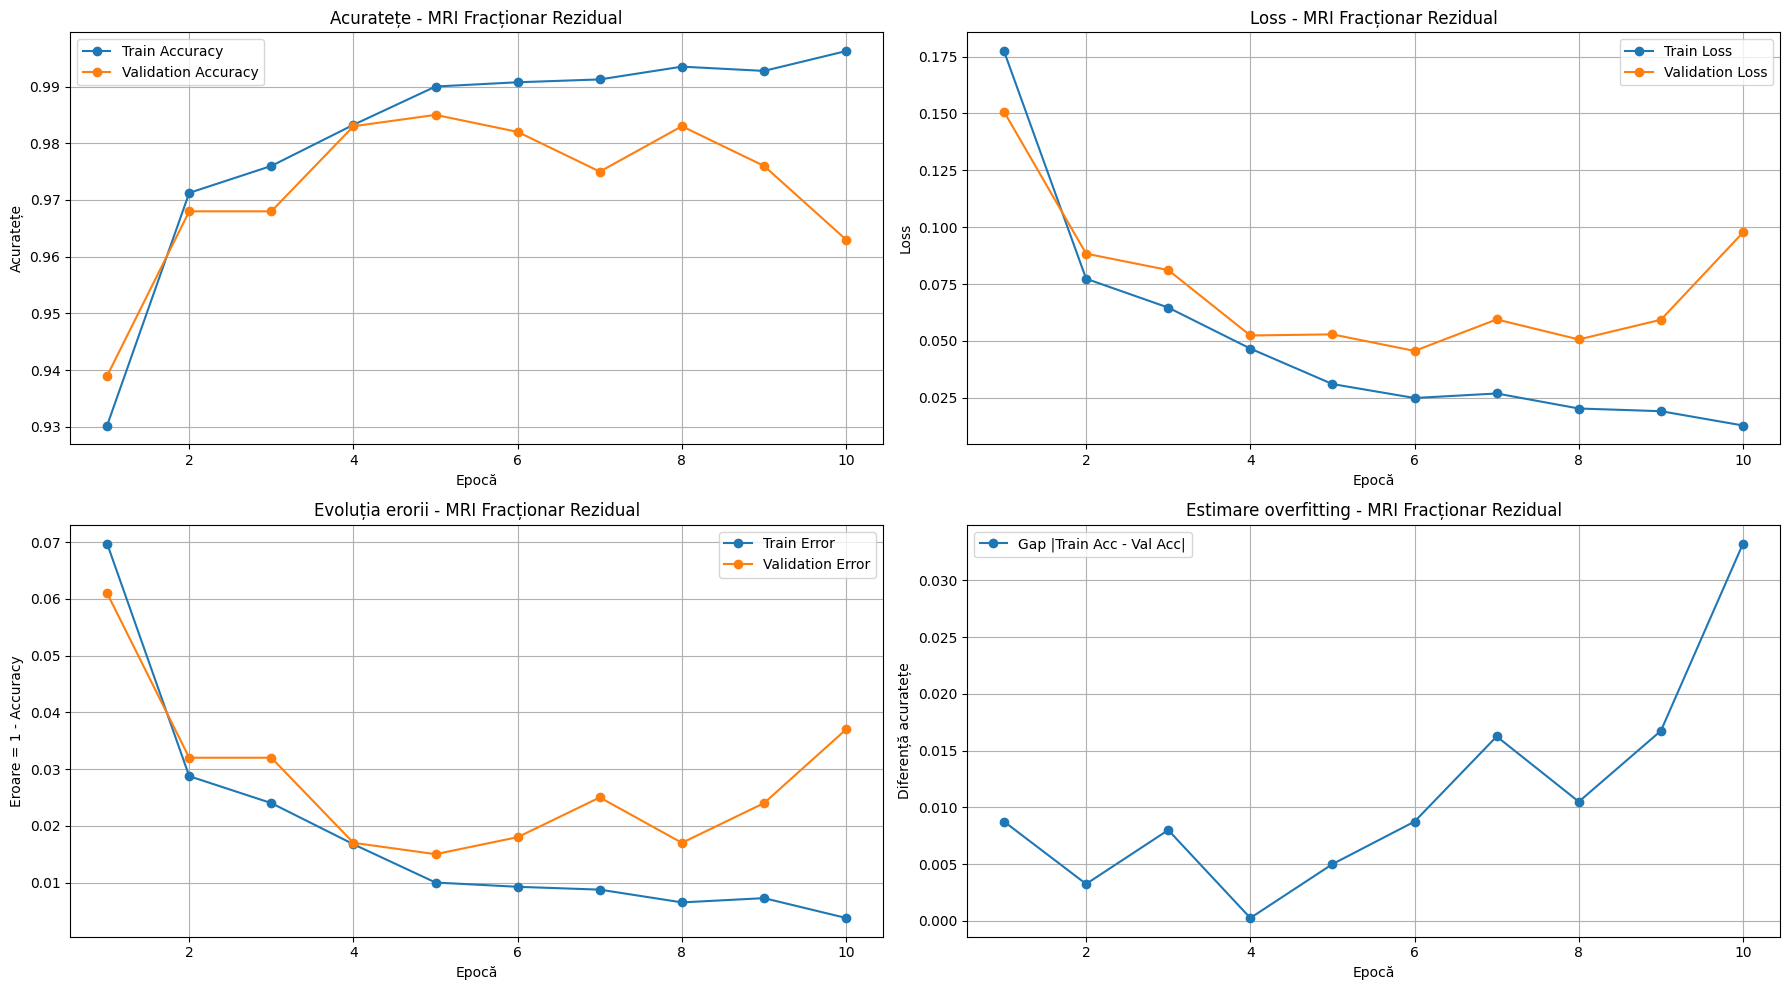

In [ ]:
plot_training_curves(history_rezidual, "MRI Fracționar Rezidual")


EVALUARE COMPLETĂ: MRI Fracționar Rezidual

Class indices:
{'Healthy': 0, 'Tumor': 1}

Rezultate model.evaluate:
loss: 0.0977
compile_metrics: 0.9630
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step

Accuracy calculată manual: 0.9630

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       0.93      0.98      0.96       400
       Tumor       0.99      0.95      0.97       600

    accuracy                           0.96      1000
   macro avg       0.96      0.97      0.96      1000
weighted avg       0.96      0.96      0.96      1000



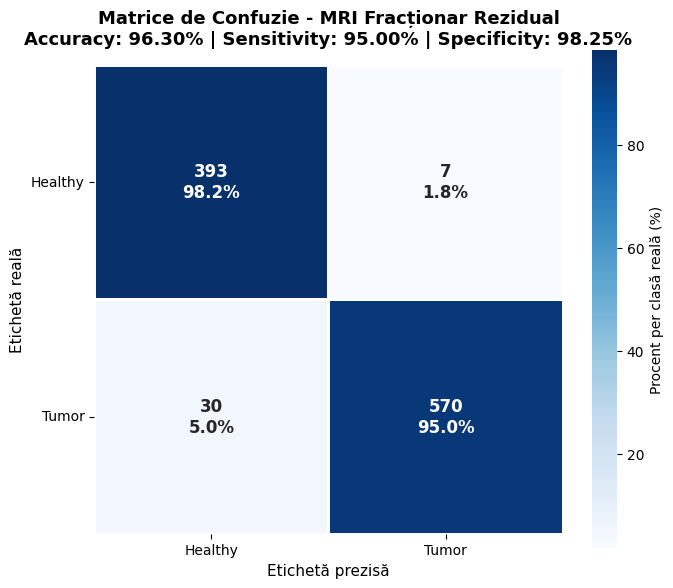

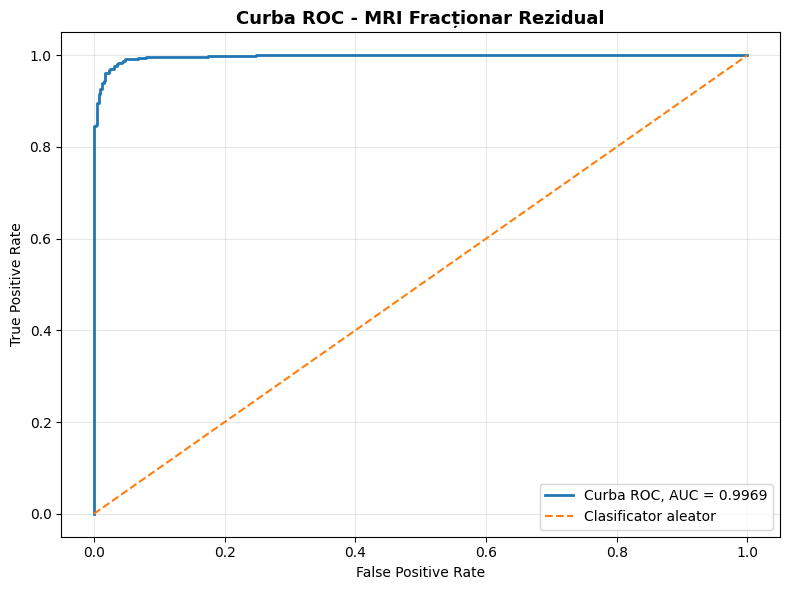

AUC ROC pentru MRI Fracționar Rezidual: 0.9969


In [ ]:
evaluate_single_input_model(model_rezidual, test_generator, "MRI Fracționar Rezidual")

In [ ]:
import os
import pandas as pd

RESULTS_DIR = "rezultate_modele"
os.makedirs(RESULTS_DIR, exist_ok=True)

test_generator.reset()
results = model_rezidual.evaluate(test_generator, verbose=0)

loss = results[0]
accuracy = results[1]

df = pd.DataFrame([{
    "model": "mri_fractional_rezidual",
    "accuracy": accuracy,
    "loss": loss
}])

fisier = os.path.join(RESULTS_DIR, "rezultate_modele.csv")

df.to_csv(
    fisier,
    mode="a",
    header=not os.path.exists(fisier),
    index=False
)

print("Rezultatele pentru mri_fractional_rezidual au fost salvate:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss/Eroare: {loss:.4f}")

Rezultatele pentru mri_fractional_rezidual au fost salvate:
Accuracy: 0.9630
Loss/Eroare: 0.0977


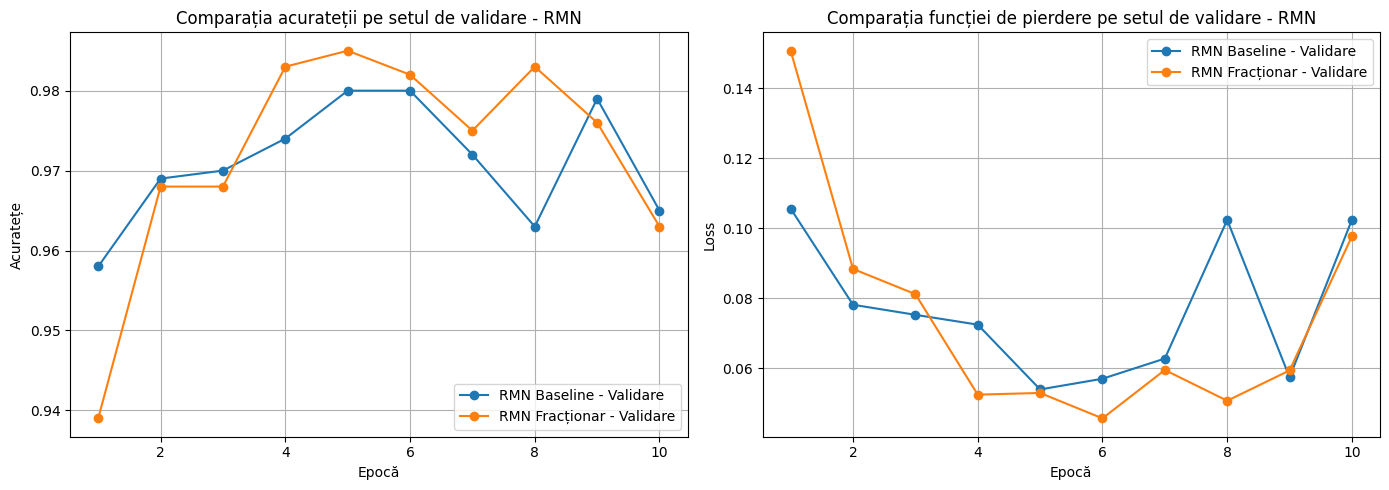

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(hist_mri_base.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Acuratețe
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    hist_mri_base.history['val_accuracy'],
    marker='o',
    label='RMN Baseline - Validare'
)
plt.plot(
    epochs_range,
    history_rezidual.history['val_accuracy'],
    marker='o',
    label='RMN Fracționar - Validare'
)

plt.title('Comparația acurateții pe setul de validare - RMN')
plt.xlabel('Epocă')
plt.ylabel('Acuratețe')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    hist_mri_base.history['val_loss'],
    marker='o',
    label='RMN Baseline - Validare'
)
plt.plot(
    epochs_range,
    history_rezidual.history['val_loss'],
    marker='o',
    label='RMN Fracționar - Validare'
)

plt.title('Comparația funcției de pierdere pe setul de validare - RMN')
plt.xlabel('Epocă')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

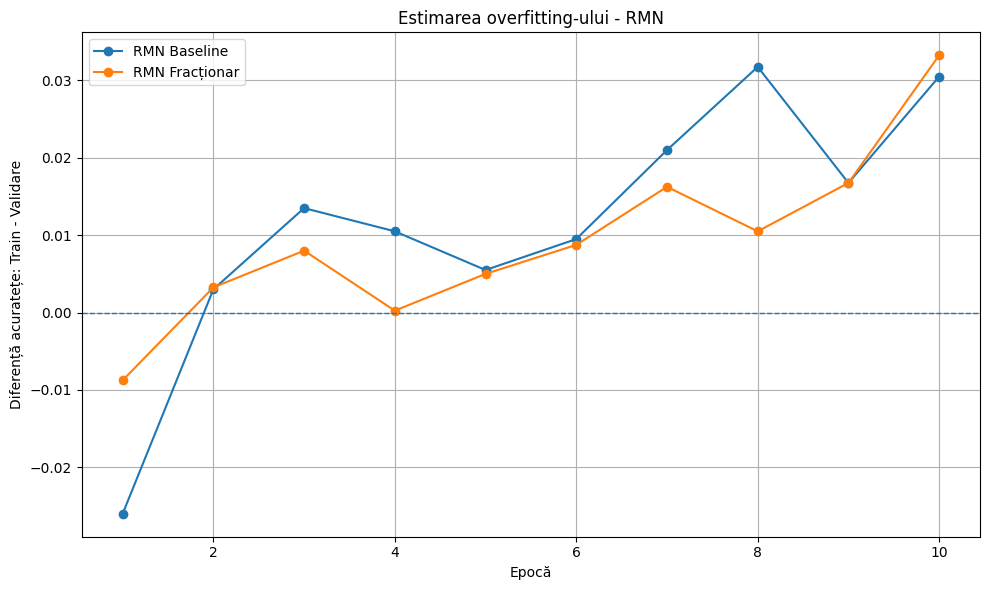

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(hist_mri_base.history["accuracy"]) + 1)

# Calcul gap overfitting: Train Accuracy - Validation Accuracy
gap_base = [
    train - val
    for train, val in zip(
        hist_mri_base.history["accuracy"],
        hist_mri_base.history["val_accuracy"]
    )
]

gap_frac = [
    train - val
    for train, val in zip(
        history_rezidual.history["accuracy"],
        history_rezidual.history["val_accuracy"]
    )
]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    gap_base,
    marker="o",
    label="RMN Baseline"
)

plt.plot(
    epochs_range,
    gap_frac,
    marker="o",
    label="RMN Fracționar"
)

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("Estimarea overfitting-ului - RMN")
plt.xlabel("Epocă")
plt.ylabel("Diferență acuratețe: Train - Validare")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

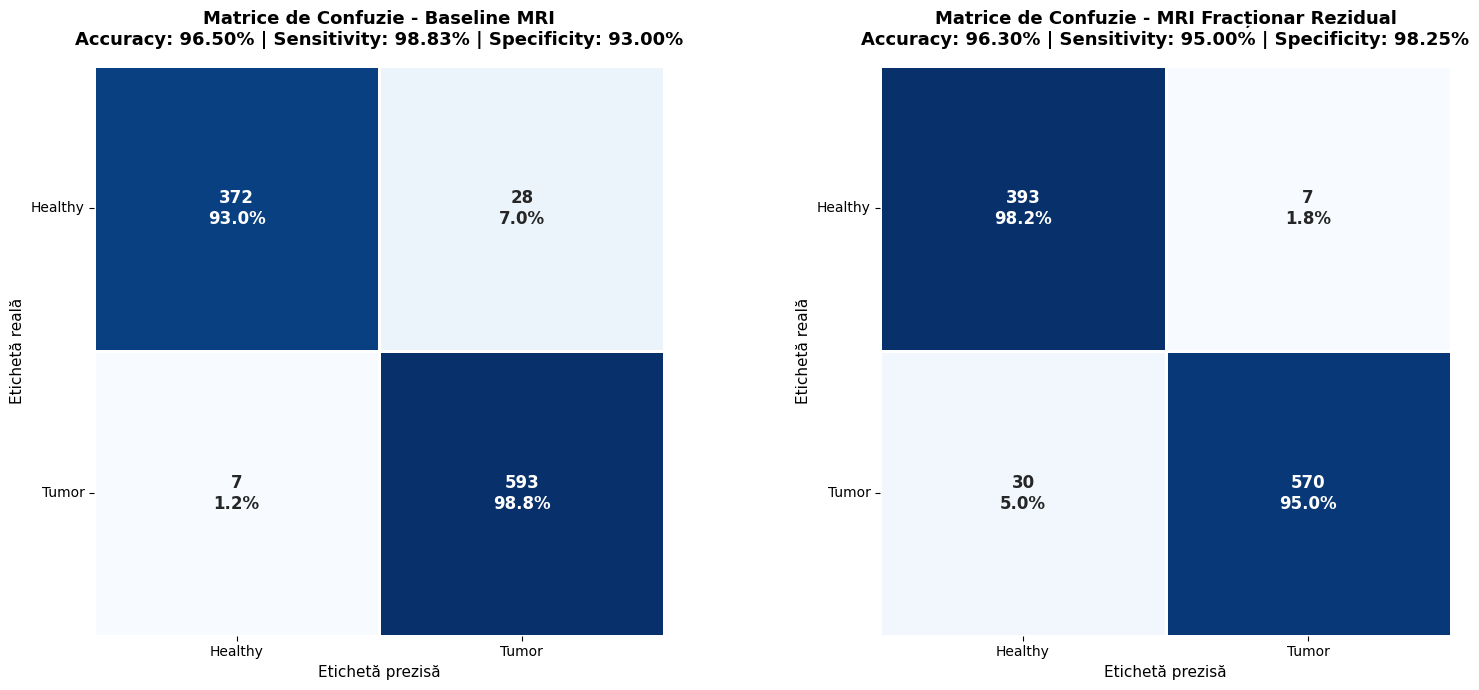

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Matricile de confuzie
#cm_baseline = np.array([
#    [372, 28],
 #   [7, 593]
#])

#cm_fractional = np.array([
#    [393, 7],
#    [30, 570]
#])

class_names = ["Healthy", "Tumor"]

def plot_confusion_matrix(ax, cm, title):
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / cm.sum()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        linewidths=1,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 12, "fontweight": "bold"},
        ax=ax
    )

    ax.set_title(
        f"{title}\n"
        f"Accuracy: {accuracy:.2%} | "
        f"Sensitivity: {sensitivity:.2%} | "
        f"Specificity: {specificity:.2%}",
        fontsize=13,
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel("Etichetă prezisă", fontsize=11)
    ax.set_ylabel("Etichetă reală", fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

# Figură comună
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_confusion_matrix(axes[0], cm_baseline, "Matrice de Confuzie - Baseline MRI")
plot_confusion_matrix(axes[1], cm_fractional, "Matrice de Confuzie - MRI Fracționar Rezidual")

plt.tight_layout()
plt.savefig("matrici_confuzie_mri_comparatie.png", dpi=300, bbox_inches="tight")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


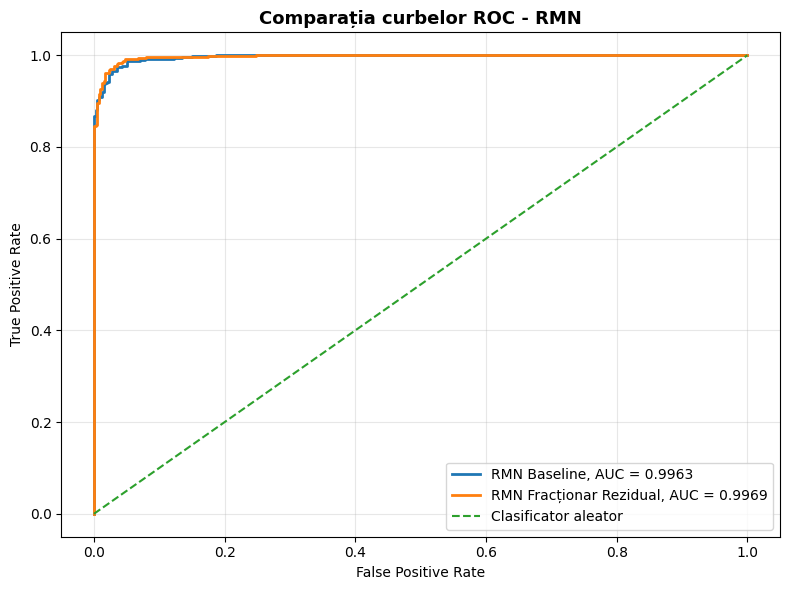

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predicții pentru modelul baseline
test_generator.reset()
y_true = test_generator.classes
y_pred_probs_base = model.predict(test_generator, verbose=1)

# Predicții pentru modelul fracționar
test_generator.reset()
y_pred_probs_frac = model_rezidual.predict(test_generator, verbose=1)

# Probabilitatea pentru clasa Tumor
y_score_base = y_pred_probs_base[:, 1]
y_score_frac = y_pred_probs_frac[:, 1]

# Calcul ROC și AUC
fpr_base, tpr_base, _ = roc_curve(y_true, y_score_base)
auc_base = auc(fpr_base, tpr_base)

fpr_frac, tpr_frac, _ = roc_curve(y_true, y_score_frac)
auc_frac = auc(fpr_frac, tpr_frac)

# Grafic comun
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_base,
    tpr_base,
    linewidth=2,
    label=f"RMN Baseline, AUC = {auc_base:.4f}"
)

plt.plot(
    fpr_frac,
    tpr_frac,
    linewidth=2,
    label=f"RMN Fracționar Rezidual, AUC = {auc_frac:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Clasificator aleator"
)

plt.title("Comparația curbelor ROC - RMN", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_mri_baseline_vs_fractional.png", dpi=300, bbox_inches="tight")
plt.show()

# **CT BASELINE**

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Folderul pentru antrenament Baseline CT: /kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor CT scan Images
Found 3695 images belonging to 2 classes.
Found 923 images belonging to 2 classes.
--- Incepem antrenamentul Baseline pentru CT ---
Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 82s 521ms/step - accuracy: 0.9112 - loss: 0.2227 - val_accuracy: 0.9209 - val_loss: 0.2663
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 19s 159ms/step - accuracy: 0.9494 - loss: 0.1368 - val_accuracy: 0.9339 - val_loss: 0.1973
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.9529 - loss: 0.1178 - val_accuracy: 0.9458 - val_loss: 0.1574
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.9651 - loss: 0.0974 - val_accuracy: 0.9491 - val_loss: 0.1620
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9697 - loss: 0.0853 - val_accuracy: 0.9350 - val_lo

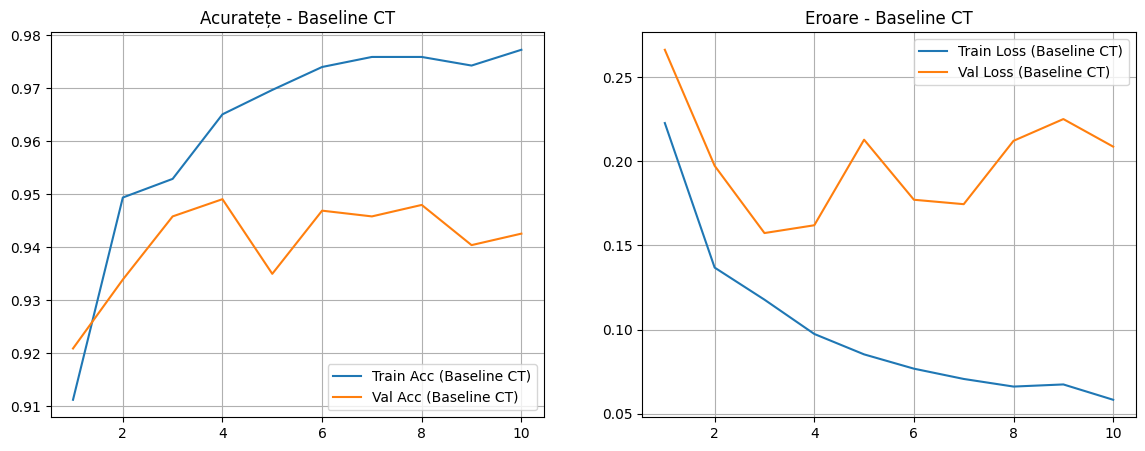

In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
base_ct_dir = os.path.join(path, "Dataset", "Brain Tumor CT scan Images")
print(f"Folderul pentru antrenament Baseline CT: {base_ct_dir}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(validation_split=0.2)

train_generator_ct = datagen.flow_from_directory(
    base_ct_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_generator_ct = datagen.flow_from_directory(
    base_ct_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# BASELINE CT
# Folosim modelul de bază, blocat
base_model_ct = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_ct.trainable = False

model_baseline_ct = models.Sequential([
    base_model_ct,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax', name="predictie_baseline_ct") # 2 clase (Healthy vs. Tumor)
])

model_baseline_ct.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ANTRENAMENT BASELINE CT ---
print("--- Incepem antrenamentul Baseline pentru CT ---")
history_baseline_ct = model_baseline_ct.fit(
    train_generator_ct,
    epochs=10,
    validation_data=test_generator_ct
)

# GRAFICE DE EVALUARE ---
acc = history_baseline_ct.history['accuracy']
val_acc = history_baseline_ct.history['val_accuracy']
loss = history_baseline_ct.history['loss']
val_loss = history_baseline_ct.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc (Baseline CT)')
plt.plot(epochs_range, val_acc, label='Val Acc (Baseline CT)')
plt.legend(loc='lower right')
plt.title('Acuratețe - Baseline CT')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss (Baseline CT)')
plt.plot(epochs_range, val_loss, label='Val Loss (Baseline CT)')
plt.legend(loc='upper right')
plt.title('Eroare - Baseline CT')
plt.grid(True)

plt.show()


EVALUARE MODEL: Baseline CT
Acuratețe finală train: 97.73%
Acuratețe finală validare: 94.26%
Cea mai bună acuratețe validare: 94.91%
Eroare finală train: 2.27%
Eroare finală validare: 5.74%
Cea mai bună estimare a erorii: 5.09%


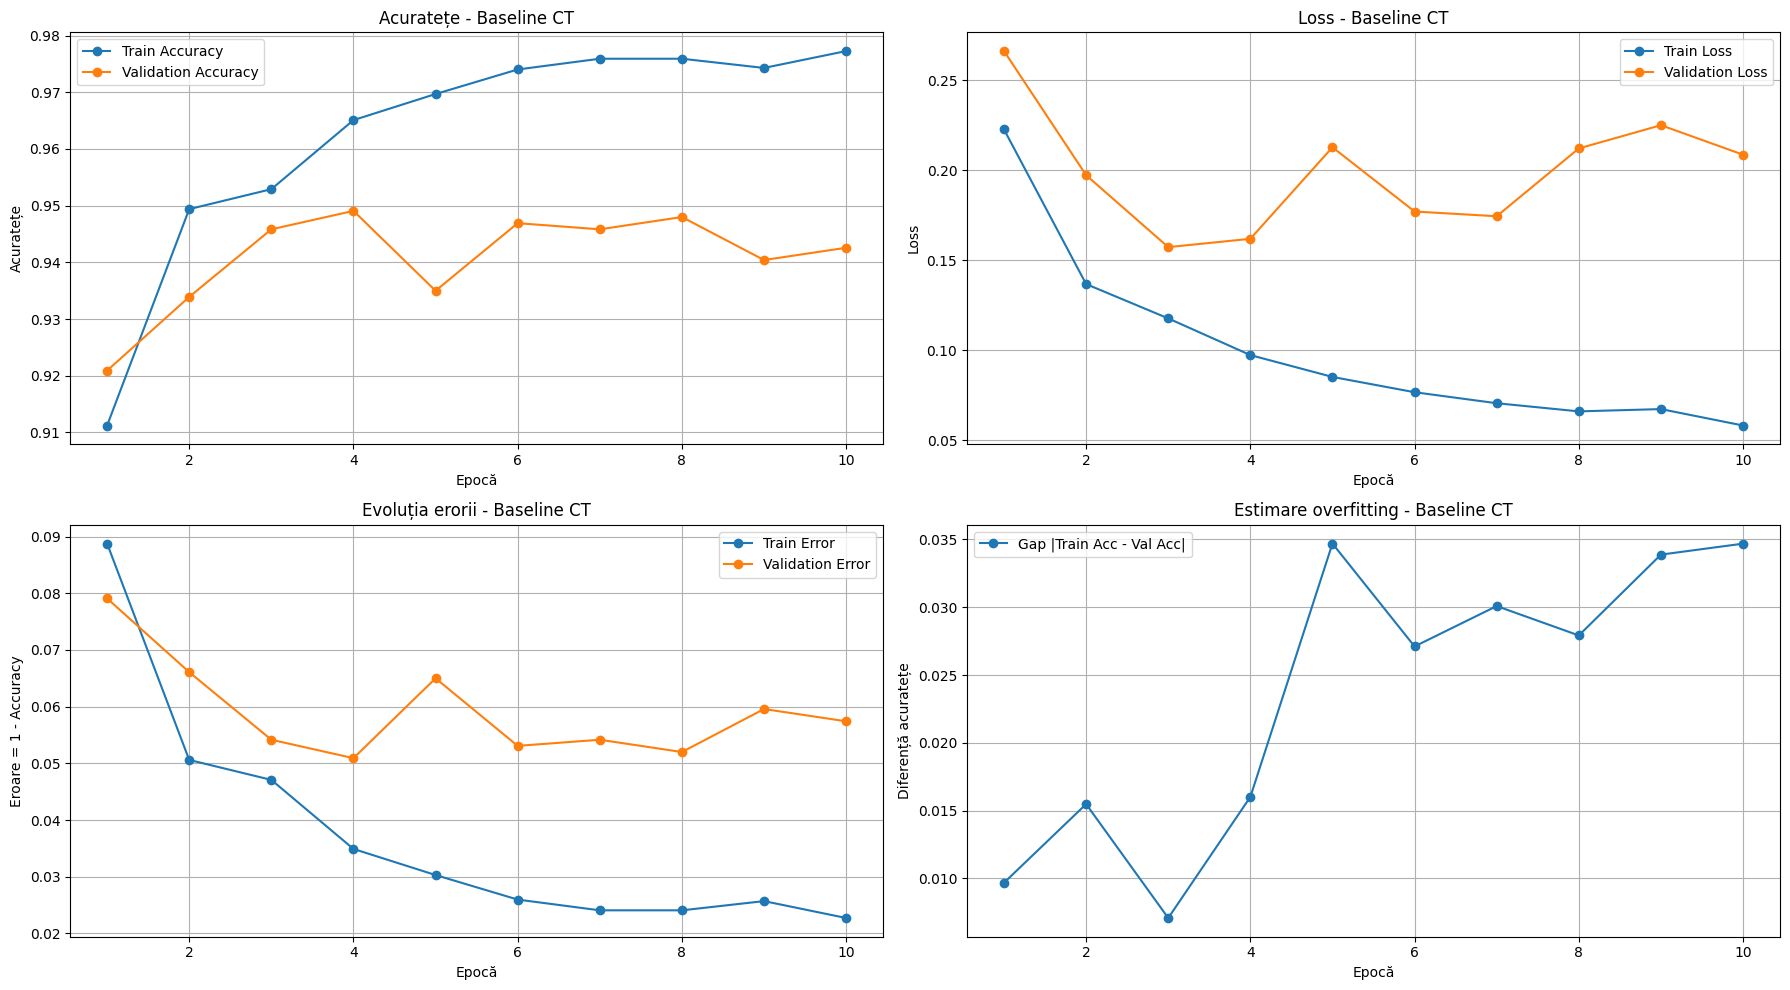

In [ ]:
plot_training_curves(history_baseline_ct, "Baseline CT")


EVALUARE COMPLETĂ: Baseline CT

Class indices:
{'Healthy': 0, 'Tumor': 1}

Rezultate model.evaluate:
loss: 0.2087
compile_metrics: 0.9426
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 355ms/step

Accuracy calculată manual: 0.9426

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       0.91      0.99      0.94       460
       Tumor       0.99      0.90      0.94       463

    accuracy                           0.94       923
   macro avg       0.95      0.94      0.94       923
weighted avg       0.95      0.94      0.94       923



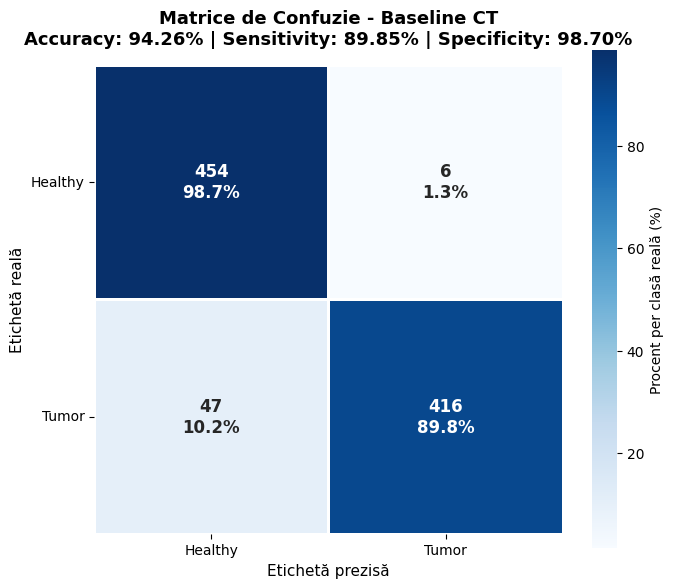

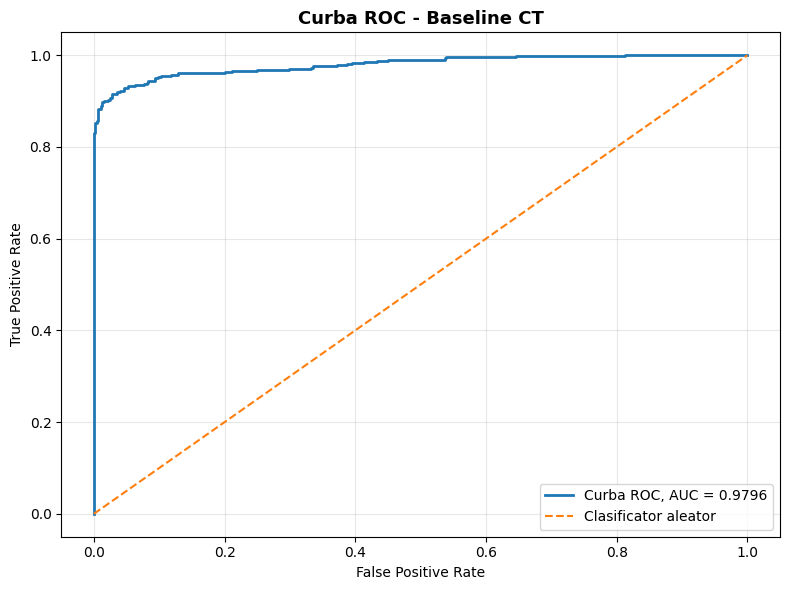

AUC ROC pentru Baseline CT: 0.9796


In [ ]:
evaluate_single_input_model(model_baseline_ct, test_generator_ct, "Baseline CT")

In [ ]:
import os
import pandas as pd

RESULTS_DIR = "rezultate_modele"
os.makedirs(RESULTS_DIR, exist_ok=True)

test_generator_ct.reset()
results = model_baseline_ct.evaluate(test_generator_ct, verbose=0)

loss = results[0]
accuracy = results[1]

df = pd.DataFrame([{
    "model": "ct_baseline",
    "accuracy": accuracy,
    "loss": loss
}])

fisier = os.path.join(RESULTS_DIR, "rezultate_modele.csv")

df.to_csv(
    fisier,
    mode="a",
    header=not os.path.exists(fisier),
    index=False
)

print("Rezultatele pentru ct_baseline au fost salvate:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss/Eroare: {loss:.4f}")

Rezultatele pentru ct_baseline au fost salvate:
Accuracy: 0.9426
Loss/Eroare: 0.2087


# **CT FRACTIONAR HIBRID**

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Folderul pentru antrenament CT: /kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor CT scan Images
Found 3695 images belonging to 2 classes.
Found 923 images belonging to 2 classes.
--- Construim Modelul Fracționar Rezidual pentru CT ---

--- Incepem antrenamentul pe date CT ---
Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 76s 438ms/step - accuracy: 0.9015 - loss: 0.2374 - val_accuracy: 0.9252 - val_loss: 0.1902
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9532 - loss: 0.1351 - val_accuracy: 0.9209 - val_loss: 0.2314
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.9629 - loss: 0.1049 - val_accuracy: 0.9361 - val_loss: 0.1842
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.9624 - loss: 0.0994 - val_accuracy: 0.9307 - val_loss: 0.1953
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9675 - loss

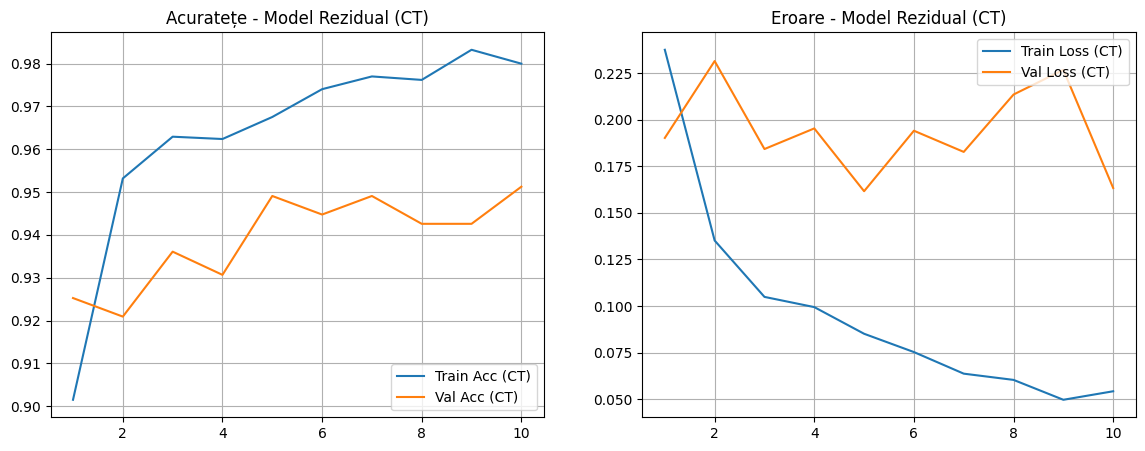

In [ ]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#------------------------------ CT ---------------------------------------------------------

path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
# am schimbat folderul tinta catre imaginile CT
base_ct_dir = os.path.join(path, "Dataset", "Brain Tumor CT scan Images")
print(f"Folderul pentru antrenament CT: {base_ct_dir}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(validation_split=0.2)

train_generator_ct = datagen.flow_from_directory(
    base_ct_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_generator_ct = datagen.flow_from_directory(
    base_ct_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ---  STRATUL FRACȚIONAR  ---
class FractionalConv2D(layers.Layer):
    def __init__(self, alpha=0.6, **kwargs):
        super(FractionalConv2D, self).__init__(**kwargs)
        self.alpha = alpha

    def build(self, input_shape):
        c0 = 1.0
        c1 = -self.alpha
        c2 = (self.alpha * (self.alpha - 1.0)) / 2.0
        mask = np.array([[c2, c1, c2], [c1, c0, c1], [c2, c1, c2]], dtype=np.float32)
        channels = input_shape[-1]
        kernel = np.zeros((3, 3, channels, 1), dtype=np.float32)
        for i in range(channels):
            kernel[:, :, i, 0] = mask
        self.kernel = tf.Variable(initial_value=kernel, trainable=False, name='fractional_kernel')

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

    def get_config(self):
        config = super(FractionalConv2D, self).get_config()
        config.update({'alpha': self.alpha})
        return config

# ---  CONSTRUIRE MODEL --
print("--- Construim Modelul Fracționar Rezidual pentru CT ---")

base_model_ct = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_ct.trainable = False

inputs_ct = Input(shape=(224, 224, 3), name="imagine_ct_intrare")

# Fracționară + Normalizare
x_fractionar_ct = FractionalConv2D(alpha=0.6)(inputs_ct)
x_fractionar_ct = layers.BatchNormalization(name="normalizare_fractionara_ct")(x_fractionar_ct)

# Conexiunea Reziduală
x_combinat_ct = layers.Add(name="conexiune_reziduala_ct")([inputs_ct, x_fractionar_ct])

#  EfficientNet
x_ct = base_model_ct(x_combinat_ct, training=False)
x_ct = layers.GlobalAveragePooling2D(name="aplatizare_ct")(x_ct)
x_ct = layers.Dense(128, activation='relu', name="rationament_128_ct")(x_ct)
x_ct = layers.Dropout(0.3, name="preventie_toceala_ct")(x_ct)
outputs_ct = layers.Dense(2, activation='softmax', name="decizie_finala_2_clase_ct")(x_ct)

model_rezidual_ct = models.Model(inputs=inputs_ct, outputs=outputs_ct, name="Model_Fractionar_Rezidual_CT")

model_rezidual_ct.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# START ANTRENAMENT PE CT ---
print("\n--- Incepem antrenamentul pe date CT ---")
history_rezidual_ct = model_rezidual_ct.fit(
    train_generator_ct,
    epochs=10,
    validation_data=test_generator_ct
)

# GRAFICE ---
acc = history_rezidual_ct.history['accuracy']
val_acc = history_rezidual_ct.history['val_accuracy']
loss = history_rezidual_ct.history['loss']
val_loss = history_rezidual_ct.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc (CT)')
plt.plot(epochs_range, val_acc, label='Val Acc (CT)')
plt.legend(loc='lower right')
plt.title('Acuratețe - Model Rezidual (CT)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss (CT)')
plt.plot(epochs_range, val_loss, label='Val Loss (CT)')
plt.legend(loc='upper right')
plt.title('Eroare - Model Rezidual (CT)')
plt.grid(True)
plt.show()


EVALUARE MODEL: CT Fracționar Rezidual
Acuratețe finală train: 98.00%
Acuratețe finală validare: 95.12%
Cea mai bună acuratețe validare: 95.12%
Eroare finală train: 2.00%
Eroare finală validare: 4.88%
Cea mai bună estimare a erorii: 4.88%


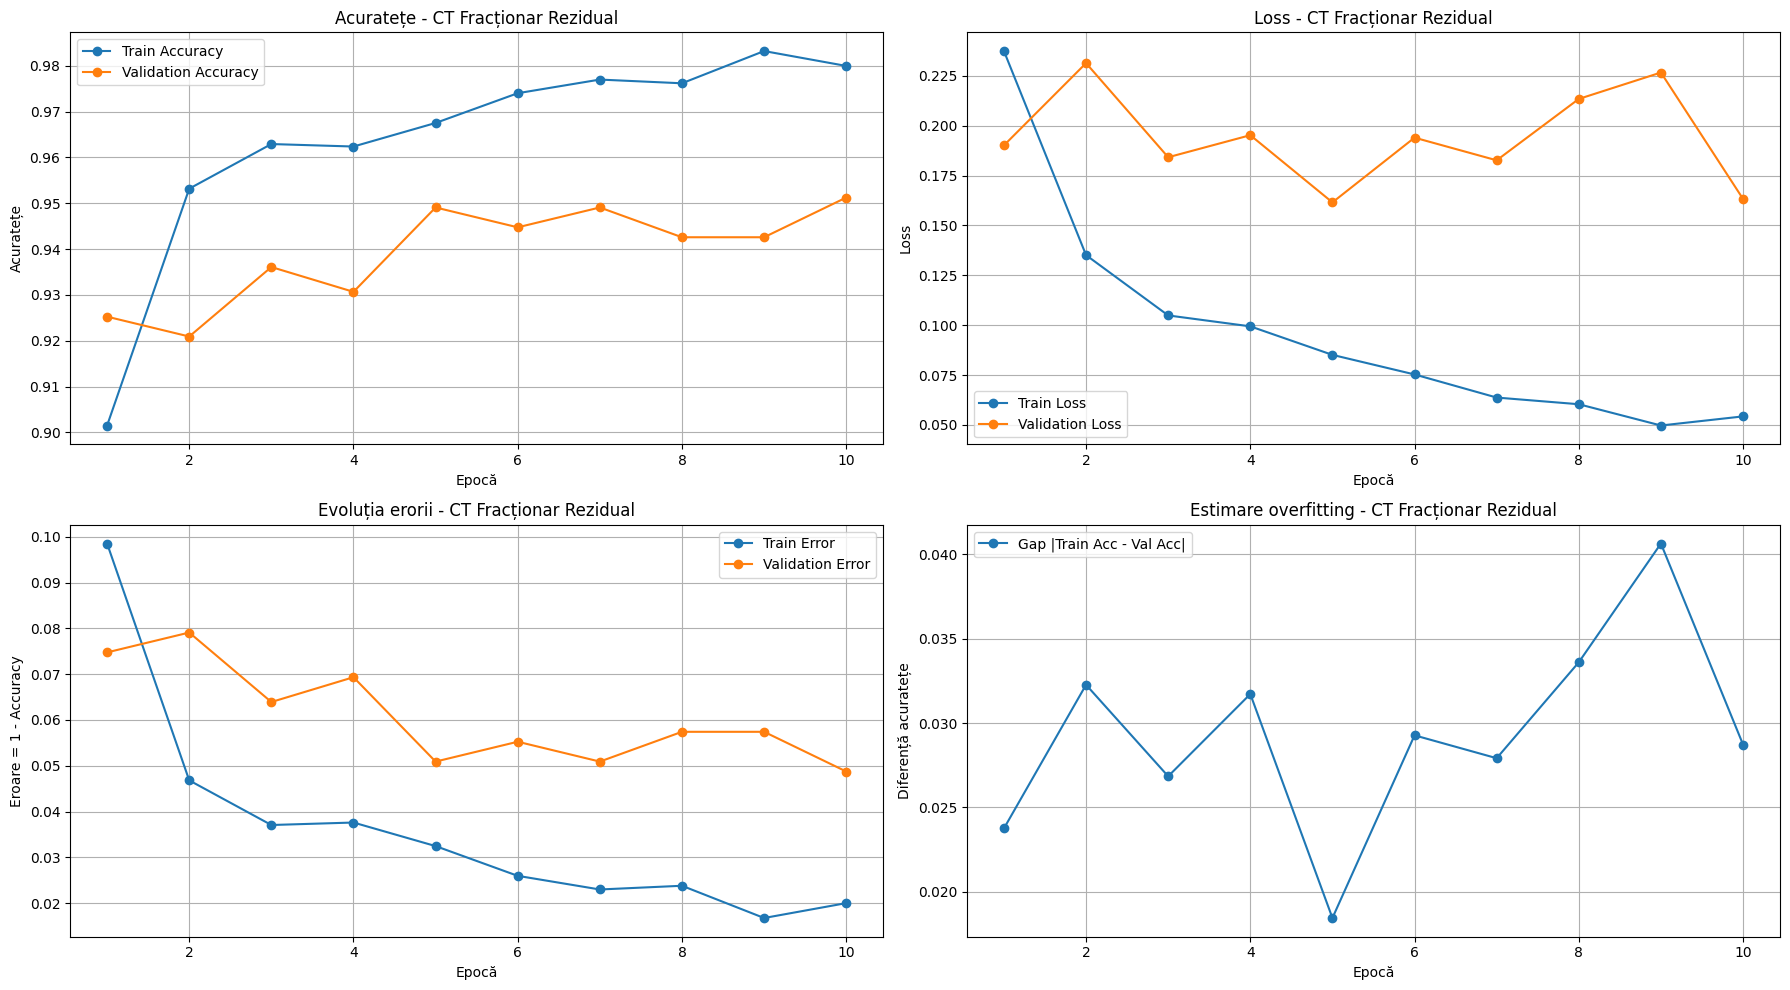

In [ ]:
plot_training_curves(history_rezidual_ct, "CT Fracționar Rezidual")


EVALUARE COMPLETĂ: CT Fracționar Rezidual

Class indices:
{'Healthy': 0, 'Tumor': 1}

Rezultate model.evaluate:
loss: 0.1633
compile_metrics: 0.9512
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 383ms/step

Accuracy calculată manual: 0.9512

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       0.93      0.98      0.95       460
       Tumor       0.98      0.92      0.95       463

    accuracy                           0.95       923
   macro avg       0.95      0.95      0.95       923
weighted avg       0.95      0.95      0.95       923



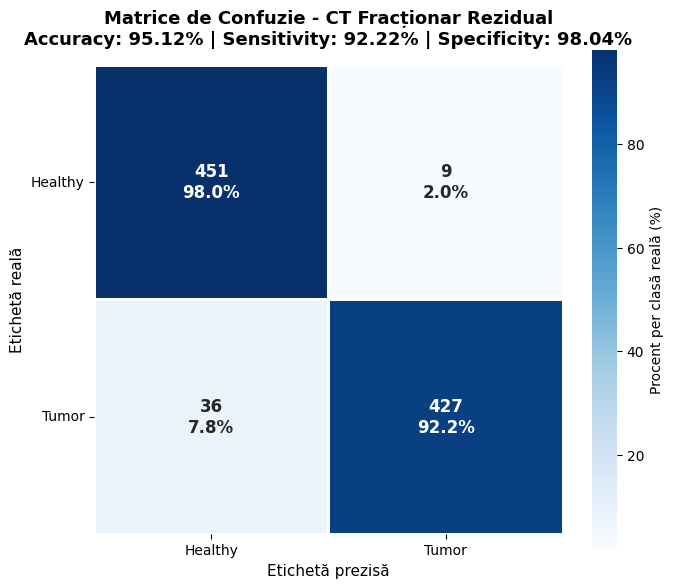

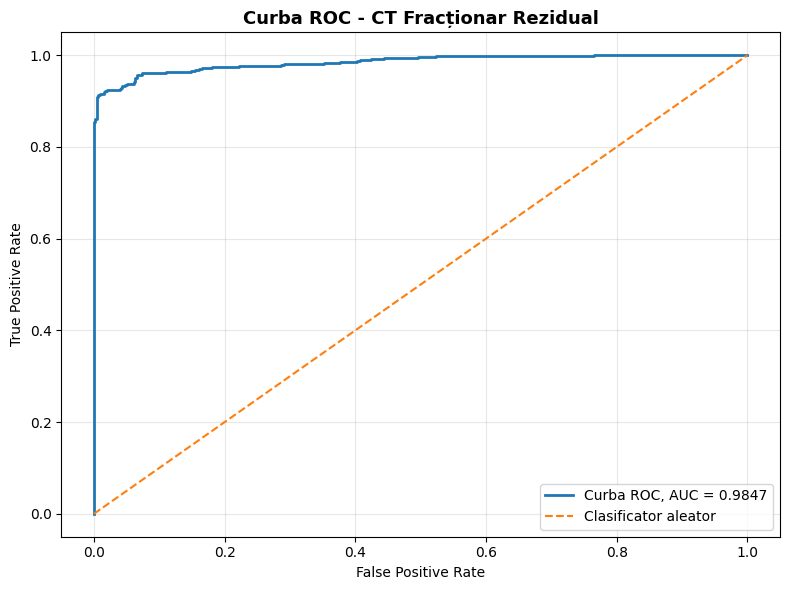

AUC ROC pentru CT Fracționar Rezidual: 0.9847


In [ ]:
evaluate_single_input_model(model_rezidual_ct, test_generator_ct, "CT Fracționar Rezidual")

In [ ]:
import os
import pandas as pd

RESULTS_DIR = "rezultate_modele"
os.makedirs(RESULTS_DIR, exist_ok=True)

test_generator_ct.reset()
results = model_rezidual_ct.evaluate(test_generator_ct, verbose=0)

loss = results[0]
accuracy = results[1]

fisier = os.path.join(RESULTS_DIR, "rezultate_modele.csv")

df = pd.DataFrame([{
    "model": "ct_fractional_rezidual",
    "accuracy": accuracy,
    "loss": loss
}])

df.to_csv(
    fisier,
    mode="a",
    header=not os.path.exists(fisier),
    index=False
)

print("Salvat în:", fisier)
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss/Eroare: {loss:.4f}")

Salvat în: rezultate_modele/rezultate_modele.csv
Accuracy: 0.9512
Loss/Eroare: 0.1633


In [ ]:
import pandas as pd

df = pd.read_csv("rezultate_modele/rezultate_modele.csv")
print(df)

                     model  accuracy      loss
0             mri_baseline  0.965000  0.102434
1  mri_fractional_rezidual  0.963000  0.097690
2              ct_baseline  0.942579  0.208700
3   ct_fractional_rezidual  0.951246  0.163293


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

fisier = "/content/drive/MyDrive/rezultate_modele.csv"

df.to_csv(
    fisier,
    mode="a",
    header=not os.path.exists(fisier),
    index=False
)

print("CSV salvat în Google Drive:", fisier)

CSV salvat în Google Drive: /content/drive/MyDrive/rezultate_modele.csv


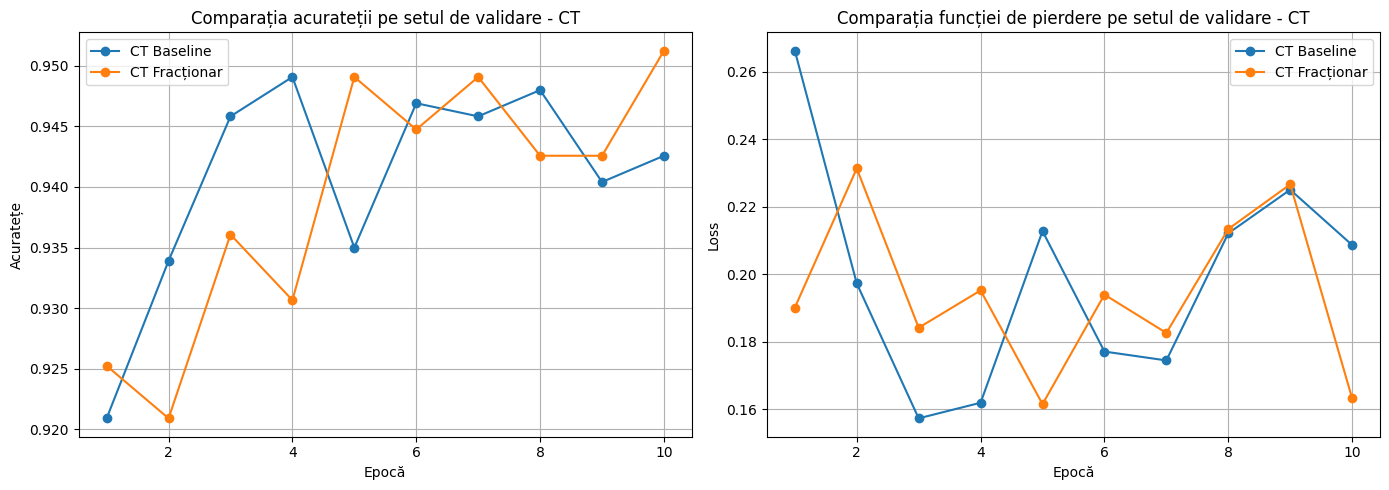

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history_baseline_ct.history["accuracy"]) + 1)

plt.figure(figsize=(14, 5))

# Acuratețe pe validare
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    history_baseline_ct.history["val_accuracy"],
    marker="o",
    label="CT Baseline"
)
plt.plot(
    epochs_range,
    history_rezidual_ct.history["val_accuracy"],
    marker="o",
    label="CT Fracționar"
)

plt.title("Comparația acurateții pe setul de validare - CT")
plt.xlabel("Epocă")
plt.ylabel("Acuratețe")
plt.legend()
plt.grid(True)

# Loss pe validare
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    history_baseline_ct.history["val_loss"],
    marker="o",
    label="CT Baseline"
)
plt.plot(
    epochs_range,
    history_rezidual_ct.history["val_loss"],
    marker="o",
    label="CT Fracționar"
)

plt.title("Comparația funcției de pierdere pe setul de validare - CT")
plt.xlabel("Epocă")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("comparatie_ct_validare_baseline_fractional.png", dpi=300, bbox_inches="tight")
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step


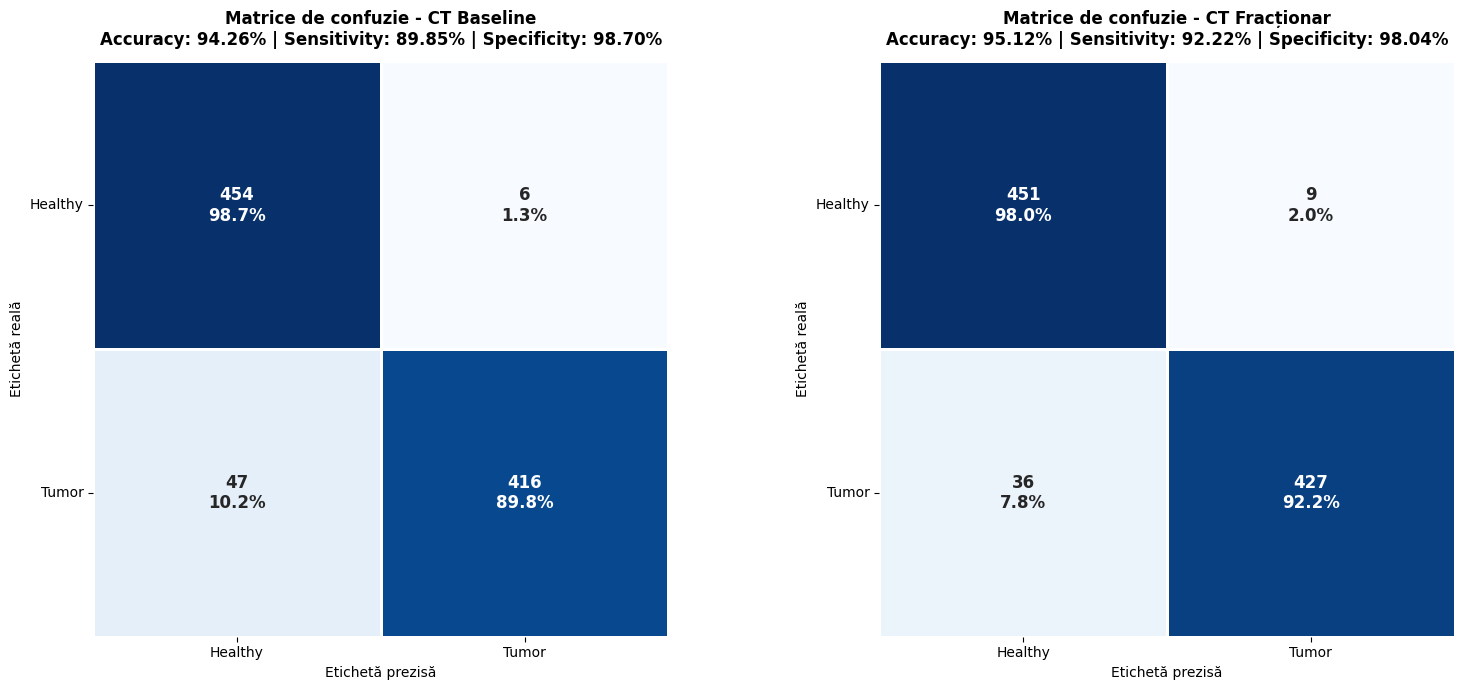

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Etichetele reale
test_generator_ct.reset()
y_true_ct = test_generator_ct.classes
class_names_ct = list(test_generator_ct.class_indices.keys())

# Predicții baseline CT
test_generator_ct.reset()
y_pred_probs_base_ct = model_baseline_ct.predict(test_generator_ct, verbose=1)
y_pred_base_ct = np.argmax(y_pred_probs_base_ct, axis=1)

# Predicții fracționar CT
test_generator_ct.reset()
y_pred_probs_frac_ct = model_rezidual_ct.predict(test_generator_ct, verbose=1)
y_pred_frac_ct = np.argmax(y_pred_probs_frac_ct, axis=1)

# Matrici de confuzie
cm_base_ct = confusion_matrix(y_true_ct, y_pred_base_ct)
cm_frac_ct = confusion_matrix(y_true_ct, y_pred_frac_ct)

def plot_confusion_matrix(ax, cm, title, class_names):
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / cm.sum()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        linewidths=1,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 12, "fontweight": "bold"},
        ax=ax
    )

    ax.set_title(
        f"{title}\n"
        f"Accuracy: {accuracy:.2%} | "
        f"Sensitivity: {sensitivity:.2%} | "
        f"Specificity: {specificity:.2%}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Etichetă prezisă")
    ax.set_ylabel("Etichetă reală")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

# Figură comună
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_confusion_matrix(
    axes[0],
    cm_base_ct,
    "Matrice de confuzie - CT Baseline",
    class_names_ct
)

plot_confusion_matrix(
    axes[1],
    cm_frac_ct,
    "Matrice de confuzie - CT Fracționar",
    class_names_ct
)

plt.tight_layout()
plt.savefig("matrici_confuzie_ct_baseline_fractional.png", dpi=300, bbox_inches="tight")
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step
Class indices CT: {'Healthy': 0, 'Tumor': 1}


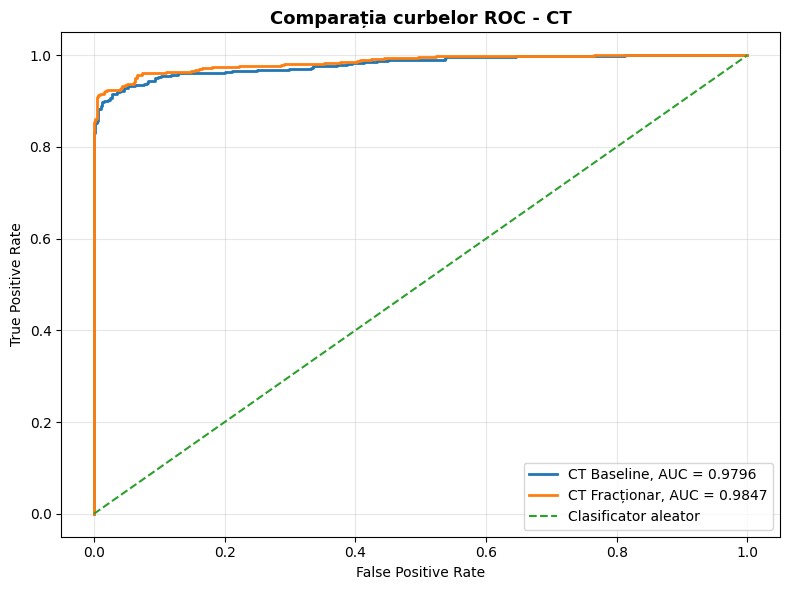

AUC CT Baseline: 0.9796
AUC CT Fracționar: 0.9847


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Etichetele reale
test_generator_ct.reset()
y_true_ct = test_generator_ct.classes

# Predicții baseline CT
test_generator_ct.reset()
y_pred_probs_base_ct = model_baseline_ct.predict(test_generator_ct, verbose=1)

# Predicții fracționar CT
test_generator_ct.reset()
y_pred_probs_frac_ct = model_rezidual_ct.predict(test_generator_ct, verbose=1)

# Probabilitatea pentru clasa Tumor
# Atenție: presupunem că Tumor este clasa cu index 1
print("Class indices CT:", test_generator_ct.class_indices)

y_score_base_ct = y_pred_probs_base_ct[:, 1]
y_score_frac_ct = y_pred_probs_frac_ct[:, 1]

# Calcul ROC și AUC
fpr_base_ct, tpr_base_ct, _ = roc_curve(y_true_ct, y_score_base_ct)
auc_base_ct = auc(fpr_base_ct, tpr_base_ct)

fpr_frac_ct, tpr_frac_ct, _ = roc_curve(y_true_ct, y_score_frac_ct)
auc_frac_ct = auc(fpr_frac_ct, tpr_frac_ct)

# Grafic comun
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_base_ct,
    tpr_base_ct,
    linewidth=2,
    label=f"CT Baseline, AUC = {auc_base_ct:.4f}"
)

plt.plot(
    fpr_frac_ct,
    tpr_frac_ct,
    linewidth=2,
    label=f"CT Fracționar, AUC = {auc_frac_ct:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Clasificator aleator"
)

plt.title("Comparația curbelor ROC - CT", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_ct_baseline_vs_fractional.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC CT Baseline: {auc_base_ct:.4f}")
print(f"AUC CT Fracționar: {auc_frac_ct:.4f}")

# **MODEL MULTIMODAL SIMPLU**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def evaluate_multimodal_model(model, test_mri, test_ct, test_y, model_name="Model Multimodal"):
    print("\n" + "=" * 60)
    print(f"EVALUARE COMPLETĂ: {model_name}")
    print("=" * 60)

    y_true = np.argmax(test_y, axis=1)

    y_pred_probs = model.predict([test_mri, test_ct])
    y_pred = np.argmax(y_pred_probs, axis=1)

    class_names = ["Healthy", "Tumor"]

    print("\nRaport de clasificare:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matrice de confuzie
    cm = confusion_matrix(y_true, y_pred)

    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / cm.sum()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    title = (
        f"Matrice de Confuzie - {model_name}\n"
        f"Accuracy: {accuracy:.2%} | "
        f"Sensitivity: {sensitivity:.2%} | "
        f"Specificity: {specificity:.2%}"
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Procent per clasă reală (%)"},
        linewidths=1,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 12, "fontweight": "bold"}
    )

    plt.title(title, fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Etichetă prezisă", fontsize=11)
    plt.ylabel("Etichetă reală", fontsize=11)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ROC
    y_score = y_pred_probs[:, 1]

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Curba ROC, AUC = {roc_auc:.4f}"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.5,
        label="Clasificator aleator"
    )

    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.title(f"Curba ROC - {model_name}", fontsize=13, fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"AUC ROC pentru {model_name}: {roc_auc:.4f}")

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "auc": roc_auc,
        "confusion_matrix": cm
    }

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import kagglehub

path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
mri_path = os.path.join(path, "Dataset", "Brain Tumor MRI images")
ct_path = os.path.join(path, "Dataset", "Brain Tumor CT scan Images")
IMG_SIZE = (224, 224)

def load_multimodal_data(mri_dir, ct_dir):
    x_mri, x_ct, y = [], [], []
    classes = ['Healthy', 'Tumor']
    for idx, cls in enumerate(classes):
        mri_cls_p = os.path.join(mri_dir, cls)
        ct_cls_p = os.path.join(ct_dir, cls)
        mri_f = sorted(os.listdir(mri_cls_p))
        ct_f = sorted(os.listdir(ct_cls_p))
        for mf, cf in zip(mri_f, ct_f):
            img_m = cv2.imread(os.path.join(mri_cls_p, mf))
            img_c = cv2.imread(os.path.join(ct_cls_p, cf))
            if img_m is not None and img_c is not None:
                x_mri.append(cv2.resize(img_m, IMG_SIZE))
                x_ct.append(cv2.resize(img_c, IMG_SIZE))
                y.append(idx)
    return np.array(x_mri), np.array(x_ct), tf.keras.utils.to_categorical(np.array(y), 2)

print("Se încarcă datele...")
X_mri, X_ct, Y = load_multimodal_data(mri_path, ct_path)
train_mri, test_mri, train_ct, test_ct, train_y, test_y = train_test_split(
    X_mri, X_ct, Y, test_size=0.2, random_state=42
)

#cONSTRUIRE ARHITECTURĂ (Weight Sharing)

base_model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False)
base_model.trainable = False

def build_baseline_branch(input_name, branch_suffix):
    inputs = Input(shape=(224, 224, 3), name=input_name)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    # Straturile Dense trebuie sa fie unice pentru fiecare ramura
    x = layers.Dense(128, activation='relu', name=f"dense_128_{branch_suffix}")(x)
    return inputs, x

# Construim cele doua intrari
in_mri, feat_mri = build_baseline_branch("mri_input", "mri")
in_ct, feat_ct = build_baseline_branch("ct_input", "ct")

# FUZIUNE
fused = layers.Concatenate(name="fuziune_baseline")([feat_mri, feat_ct])
z = layers.Dense(64, activation='relu', name="rationament_comun")(fused)
z = layers.Dropout(0.3)(z)
output = layers.Dense(2, activation='softmax', name="decizie_finala")(z)

model_multimodal = models.Model(inputs=[in_mri, in_ct], outputs=output)

model_multimodal.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ANTRENAMENT
print("\n--- Începem Antrenamentul Baseline Multimodal (Shared Weights) ---")
history_multimodal_baseline = model_multimodal.fit(
    [train_mri, train_ct], train_y,
    validation_data=([test_mri, test_ct], test_y),
    epochs=10,
    batch_size=32
)

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Se încarcă datele...

--- Începem Antrenamentul Baseline Multimodal (Shared Weights) ---
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 86s 430ms/step - accuracy: 0.9606 - loss: 0.1004 - val_accuracy: 0.9931 - val_loss: 0.0262
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9893 - loss: 0.0294 - val_accuracy: 0.9919 - val_loss: 0.0214
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9954 - loss: 0.0146 - val_accuracy: 0.9931 - val_loss: 0.0225
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9933 - loss: 0.0215 - val_accuracy: 0.9954 - val_loss: 0.0110
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9948 - loss: 0.0140 - val_accuracy: 0.9965 - val_loss: 0.0122
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9988 - loss: 0.0053 - val_accuracy: 0.9942 - val_loss: 0.0135
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 


EVALUARE MODEL: Fuziune Normală MRI + CT
Acuratețe finală train: 99.68%
Acuratețe finală validare: 98.96%
Cea mai bună acuratețe validare: 99.65%
Eroare finală train: 0.32%
Eroare finală validare: 1.04%
Cea mai bună estimare a erorii: 0.35%


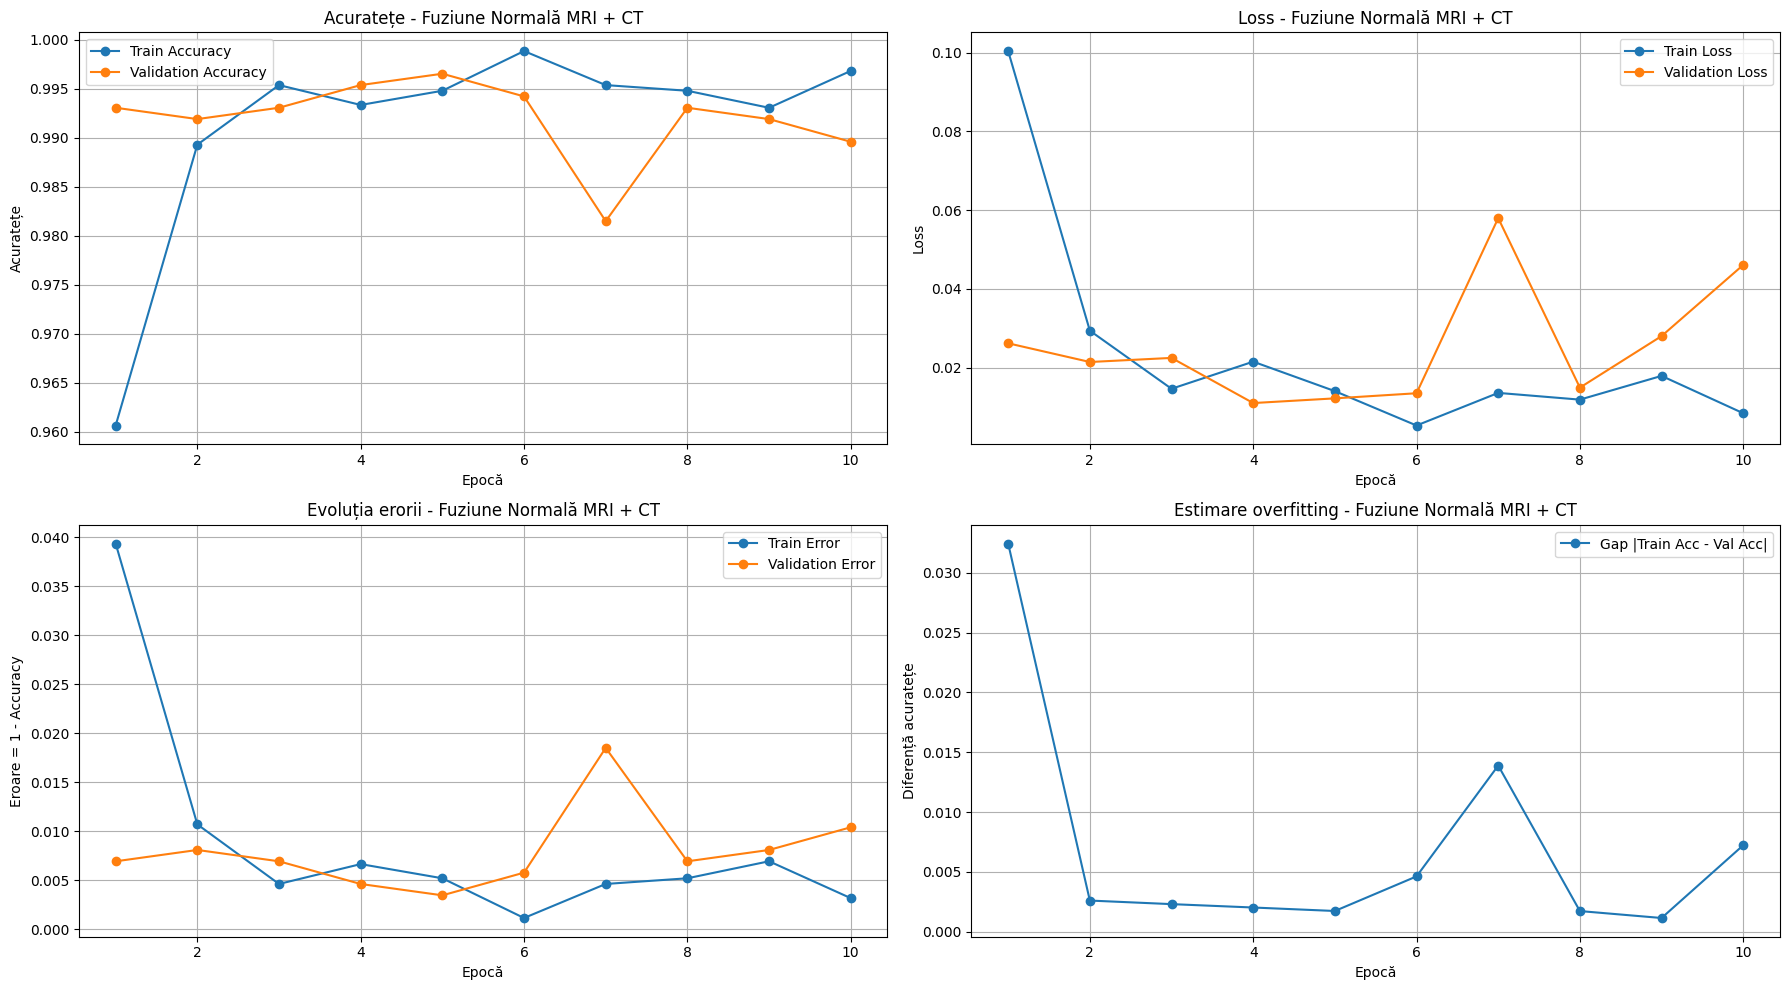

In [ ]:
plot_training_curves(history_multimodal_baseline, "Fuziune Normală MRI + CT")


EVALUARE COMPLETĂ: Fuziune Normală MRI + CT
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       1.00      0.98      0.99       428
       Tumor       0.98      1.00      0.99       436

    accuracy                           0.99       864
   macro avg       0.99      0.99      0.99       864
weighted avg       0.99      0.99      0.99       864



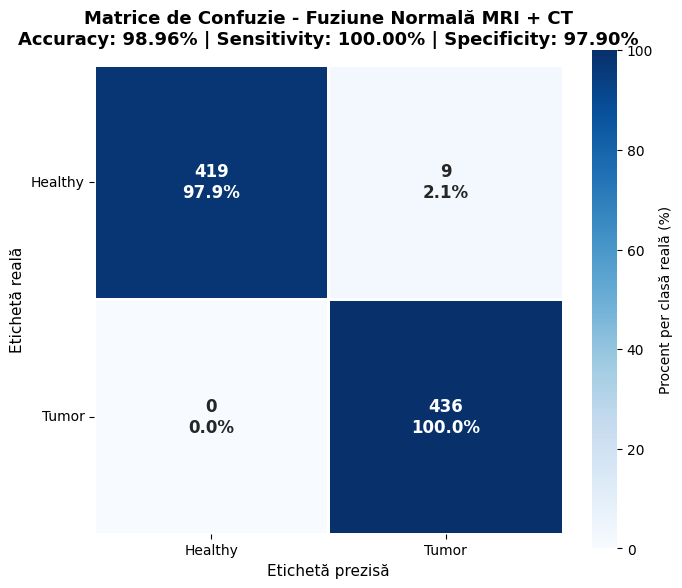

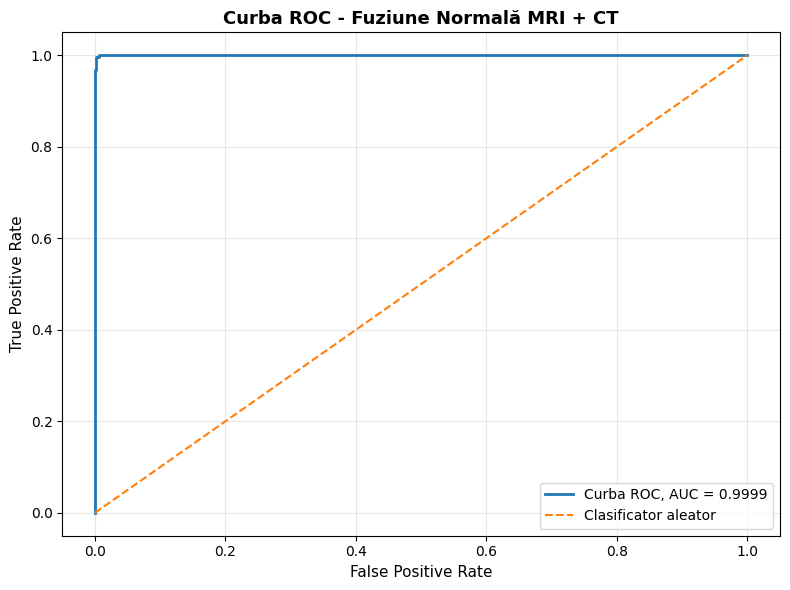

AUC ROC pentru Fuziune Normală MRI + CT: 0.9999


In [ ]:
rezultate_baseline_multimodal = evaluate_multimodal_model(
    model_multimodal,
    test_mri,
    test_ct,
    test_y,
    "Fuziune Normală MRI + CT"
)

# **MULTIMODAL FRACTIONAR**

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import kagglehub


path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
mri_path = os.path.join(path, "Dataset", "Brain Tumor MRI images")
ct_path = os.path.join(path, "Dataset", "Brain Tumor CT scan Images")
IMG_SIZE = (224, 224)

def load_multimodal_data(mri_dir, ct_dir):
    x_mri, x_ct, y = [], [], []
    classes = ['Healthy', 'Tumor']
    for idx, cls in enumerate(classes):
        mri_cls_p = os.path.join(mri_dir, cls)
        ct_cls_p = os.path.join(ct_dir, cls)
        mri_f = sorted(os.listdir(mri_cls_p))
        ct_f = sorted(os.listdir(ct_cls_p))
        for mf, cf in zip(mri_f, ct_f):
            img_m = cv2.imread(os.path.join(mri_cls_p, mf))
            img_c = cv2.imread(os.path.join(ct_cls_p, cf))
            if img_m is not None and img_c is not None:
                x_mri.append(cv2.resize(img_m, IMG_SIZE))
                x_ct.append(cv2.resize(img_c, IMG_SIZE))
                y.append(idx)
    return np.array(x_mri), np.array(x_ct), tf.keras.utils.to_categorical(np.array(y), 2)

print("Se încarcă datele (MRI + CT)...")
X_mri, X_ct, Y = load_multimodal_data(mri_path, ct_path)
train_mri, test_mri, train_ct, test_ct, train_y, test_y = train_test_split(
    X_mri, X_ct, Y, test_size=0.2, random_state=42
)

class FractionalConv2D(layers.Layer):
    def __init__(self, alpha=0.6, **kwargs):
        super(FractionalConv2D, self).__init__(**kwargs)
        self.alpha = alpha

    def build(self, input_shape):
        c0, c1, c2 = 1.0, -self.alpha, (self.alpha * (self.alpha - 1.0)) / 2.0
        mask = np.array([[c2, c1, c2], [c1, c0, c1], [c2, c1, c2]], dtype=np.float32)
        channels = input_shape[-1]
        kernel = np.zeros((3, 3, channels, 1), dtype=np.float32)
        for i in range(channels): kernel[:, :, i, 0] = mask
        self.kernel = tf.Variable(initial_value=kernel, trainable=False, name='fractional_kernel')

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

# ARHITECTURA MULTIMODALĂ FRACȚIONARĂ REZIDUALĂ ---
base_model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False)
base_model.trainable = False

def build_fractional_branch(input_name, branch_suffix):
    # Intrarea imaginii
    inputs = Input(shape=(224, 224, 3), name=input_name)

    # Fracționară
    x_f = FractionalConv2D(alpha=0.6)(inputs)
    x_f = layers.BatchNormalization(name=f"bn_{branch_suffix}")(x_f)

    # 2. Fuziune Reziduală (Imagine Originală + Detalii Fracționare)
    x_res = layers.Add(name=f"residual_{branch_suffix}")([inputs, x_f])

    # 3. Extracție Trăsături (EfficientNet Shared)
    x = base_model(x_res, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', name=f"fc_{branch_suffix}")(x)
    return inputs, x


in_mri, feat_mri = build_fractional_branch("mri_input", "mri")
in_ct, feat_ct = build_fractional_branch("ct_input", "ct")

fused = layers.Concatenate(name="fuziune_finala")([feat_mri, feat_ct])
z = layers.Dense(64, activation='relu', name="rationament_multimodal")(fused)
z = layers.Dropout(0.4)(z)
output = layers.Dense(2, activation='softmax', name="decizie")(z)

model_fractionar_multimodal = models.Model(inputs=[in_mri, in_ct], outputs=output)

model_fractionar_multimodal.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# START ANTRENAMENT ---
print("\n--- Incepem Antrenamentul Multimodal Fracționar Rezidual ---")
history_multimodal_fractionar = model_fractionar_multimodal.fit(
    [train_mri, train_ct], train_y,
    validation_data=([test_mri, test_ct], test_y),
    epochs=10,
    batch_size=32
)

# --- 6. GRAFICE ---
#plt.figure(figsize=(12, 4))
#plt.subplot(1, 2, 1)
#plt.plot(history.history['accuracy'], label='Train Acc')
#plt.plot(history.history['val_accuracy'], label='Val Acc')
#plt.title('Acuratețe Multimodal Fracționar')
#plt.legend()
#plt.show()

Using Colab cache for faster access to the 'brain-tumor-multimodal-image-ct-and-mri' dataset.
Se încarcă datele (MRI + CT)...

--- Incepem Antrenamentul Multimodal Fracționar Rezidual ---
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 111s 571ms/step - accuracy: 0.9572 - loss: 0.1045 - val_accuracy: 0.9896 - val_loss: 0.0337
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - accuracy: 0.9861 - loss: 0.0386 - val_accuracy: 0.9942 - val_loss: 0.0226
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.9919 - loss: 0.0197 - val_accuracy: 0.9826 - val_loss: 0.0599
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.9931 - val_loss: 0.0245
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0.9954 - val_loss: 0.0200
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9931 - val_loss: 0.0244
Epoch 7/10
108/108 ━━━━━━


EVALUARE MODEL: Fuziune Fracționară Reziduală MRI + CT
Acuratețe finală train: 99.91%
Acuratețe finală validare: 99.54%
Cea mai bună acuratețe validare: 99.54%
Eroare finală train: 0.09%
Eroare finală validare: 0.46%
Cea mai bună estimare a erorii: 0.46%


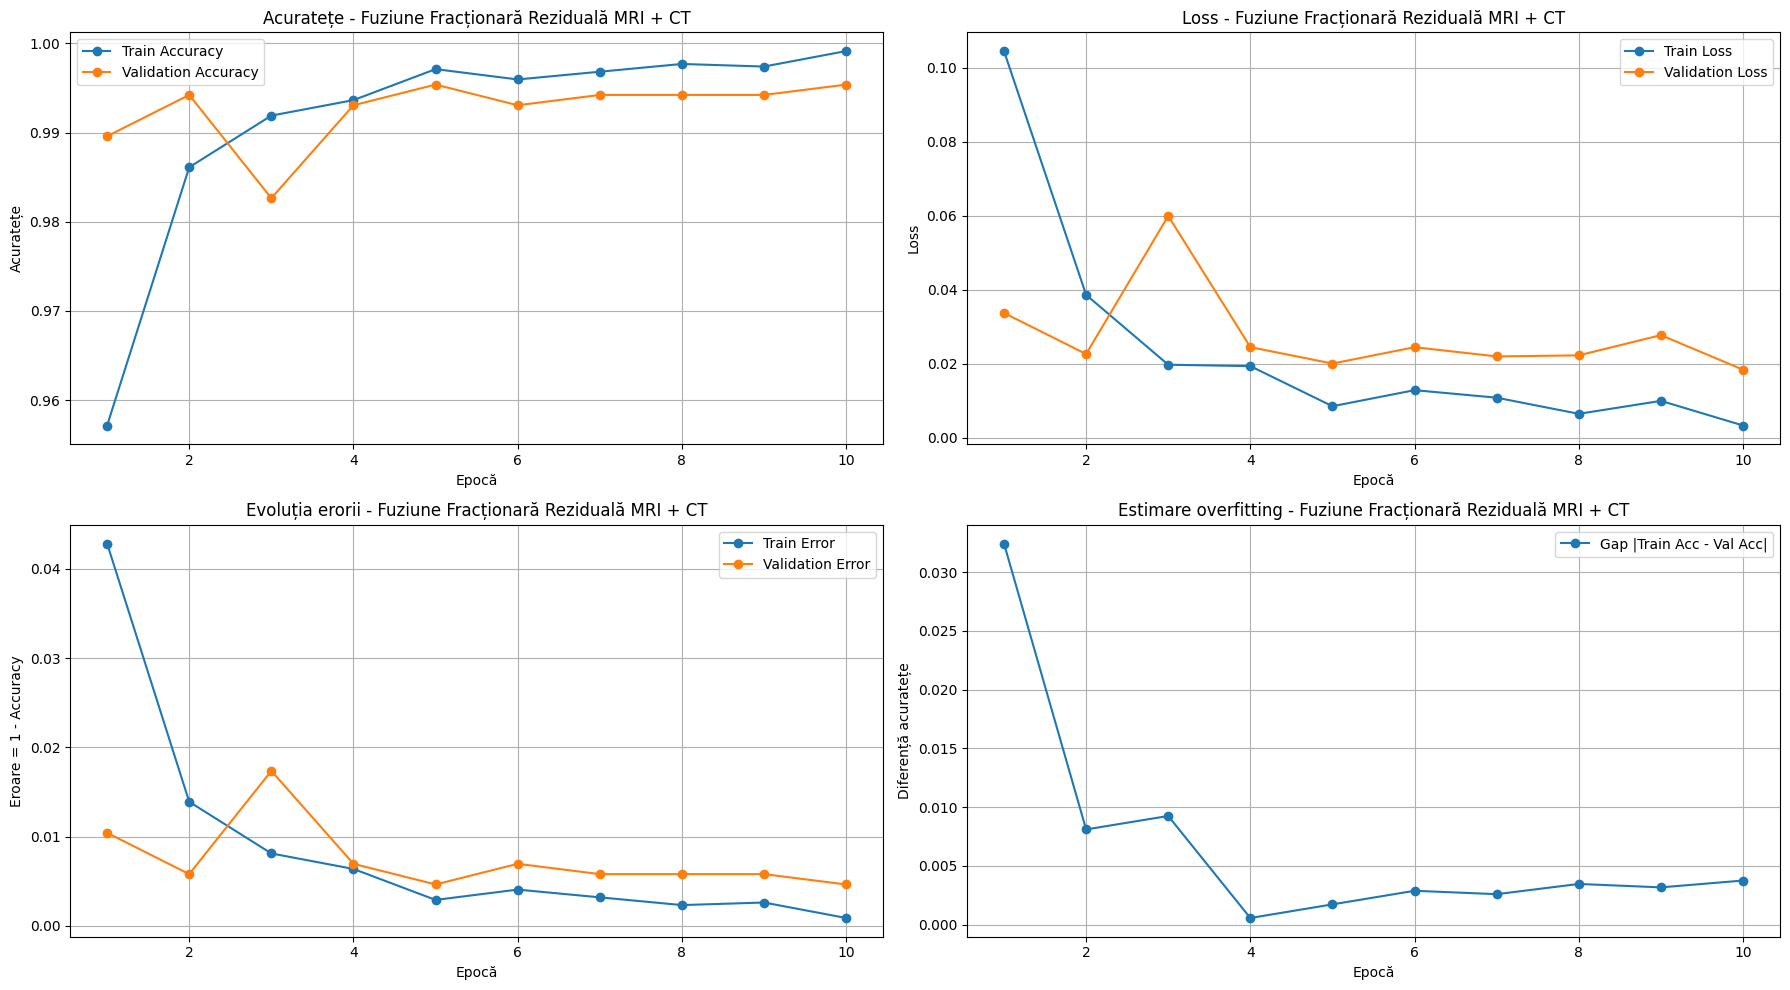

In [ ]:
plot_training_curves(history_multimodal_fractionar, "Fuziune Fracționară Reziduală MRI + CT")


EVALUARE COMPLETĂ: Fuziune Fracționară Reziduală MRI + CT
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step

Raport de clasificare:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       428
       Tumor       1.00      1.00      1.00       436

    accuracy                           1.00       864
   macro avg       1.00      1.00      1.00       864
weighted avg       1.00      1.00      1.00       864



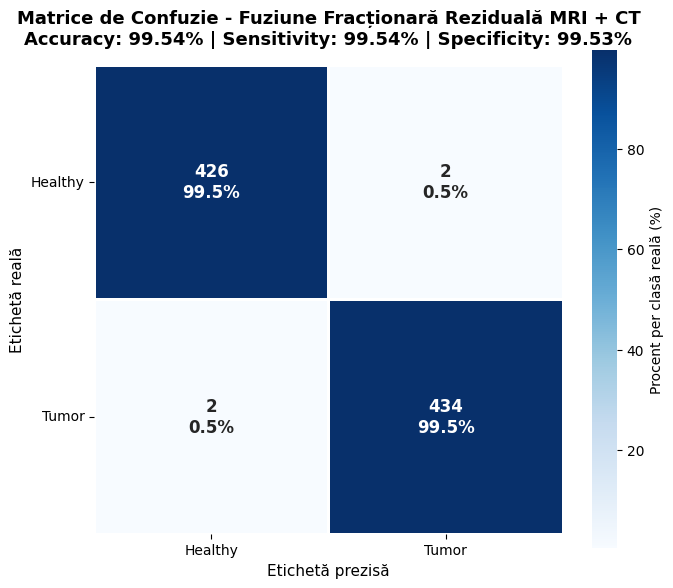

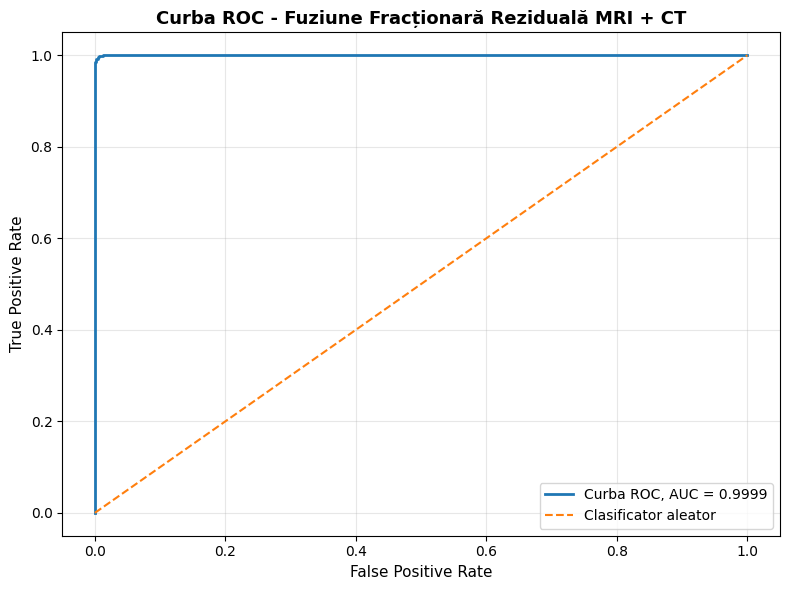

AUC ROC pentru Fuziune Fracționară Reziduală MRI + CT: 0.9999


In [ ]:
rezultate_fractionar_multimodal = evaluate_multimodal_model(
    model_fractionar_multimodal,
    test_mri,
    test_ct,
    test_y,
    "Fuziune Fracționară Reziduală MRI + CT"
)

In [ ]:
loss_baseline, acc_baseline = model_multimodal.evaluate(
    [test_mri, test_ct],
    test_y,
    verbose=0
)

loss_fractional, acc_fractional = model_fractionar_multimodal.evaluate(
    [test_mri, test_ct],
    test_y,
    verbose=0
)

print("Multimodal Baseline:", acc_baseline, loss_baseline)
print("Multimodal Fractional:", acc_fractional, loss_fractional)

Multimodal Baseline: 0.9895833134651184 0.046085286885499954
Multimodal Fractional: 0.9953703880310059 0.018342887982726097


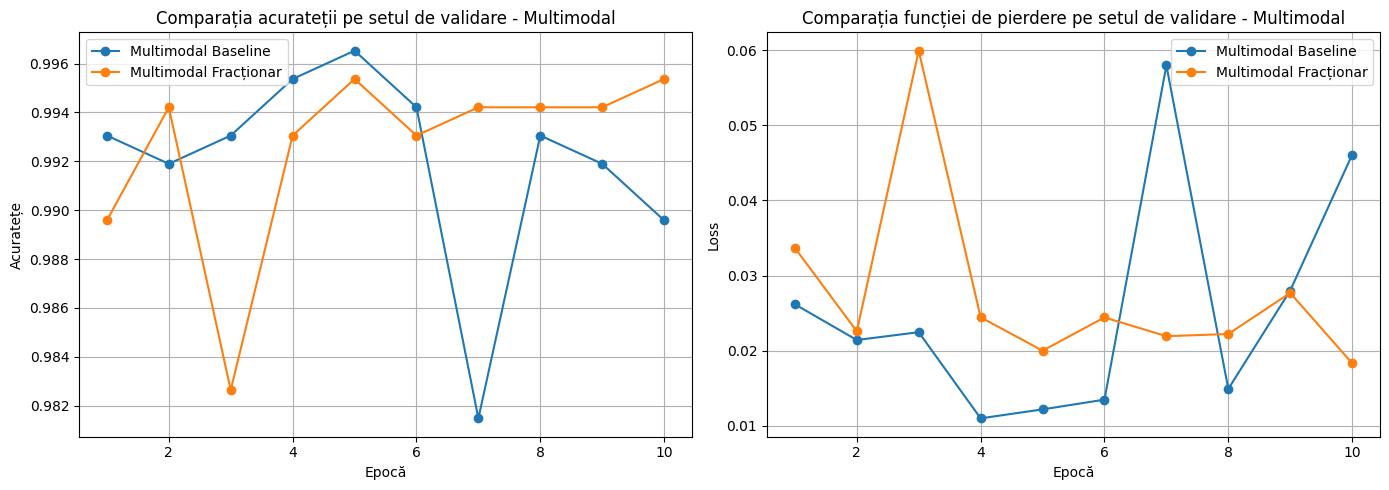

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history_multimodal_baseline.history["accuracy"]) + 1)

plt.figure(figsize=(14, 5))

# Acuratețe validare
plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    history_multimodal_baseline.history["val_accuracy"],
    marker="o",
    label="Multimodal Baseline"
)

plt.plot(
    epochs_range,
    history_multimodal_fractionar.history["val_accuracy"],
    marker="o",
    label="Multimodal Fracționar"
)

plt.title("Comparația acurateții pe setul de validare - Multimodal")
plt.xlabel("Epocă")
plt.ylabel("Acuratețe")
plt.legend()
plt.grid(True)

# Loss validare
plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    history_multimodal_baseline.history["val_loss"],
    marker="o",
    label="Multimodal Baseline"
)

plt.plot(
    epochs_range,
    history_multimodal_fractionar.history["val_loss"],
    marker="o",
    label="Multimodal Fracționar"
)

plt.title("Comparația funcției de pierdere pe setul de validare - Multimodal")
plt.xlabel("Epocă")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("comparatie_multimodal_validare_baseline_fractional.png", dpi=300, bbox_inches="tight")
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step


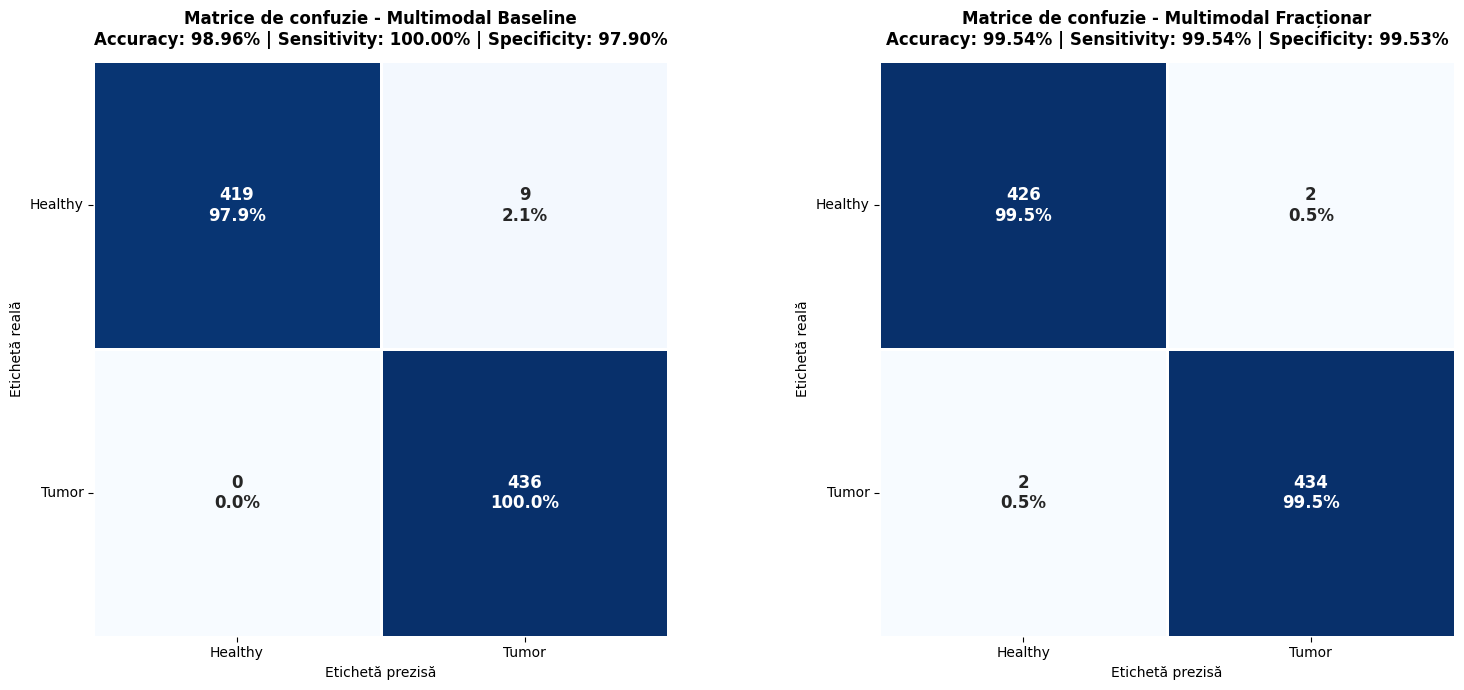

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["Healthy", "Tumor"]

# Etichete reale
y_true = np.argmax(test_y, axis=1)

# Predicții baseline
y_pred_probs_base = model_multimodal.predict([test_mri, test_ct], verbose=1)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)

# Predicții fracționar
y_pred_probs_frac = model_fractionar_multimodal.predict([test_mri, test_ct], verbose=1)
y_pred_frac = np.argmax(y_pred_probs_frac, axis=1)

# Matrici de confuzie
cm_base = confusion_matrix(y_true, y_pred_base)
cm_frac = confusion_matrix(y_true, y_pred_frac)

def plot_confusion_matrix(ax, cm, title, class_names):
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / cm.sum()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        linewidths=1,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 12, "fontweight": "bold"},
        ax=ax
    )

    ax.set_title(
        f"{title}\n"
        f"Accuracy: {accuracy:.2%} | "
        f"Sensitivity: {sensitivity:.2%} | "
        f"Specificity: {specificity:.2%}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Etichetă prezisă")
    ax.set_ylabel("Etichetă reală")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_confusion_matrix(
    axes[0],
    cm_base,
    "Matrice de confuzie - Multimodal Baseline",
    class_names
)

plot_confusion_matrix(
    axes[1],
    cm_frac,
    "Matrice de confuzie - Multimodal Fracționar",
    class_names
)

plt.tight_layout()
plt.savefig("matrici_confuzie_multimodal.png", dpi=300, bbox_inches="tight")
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


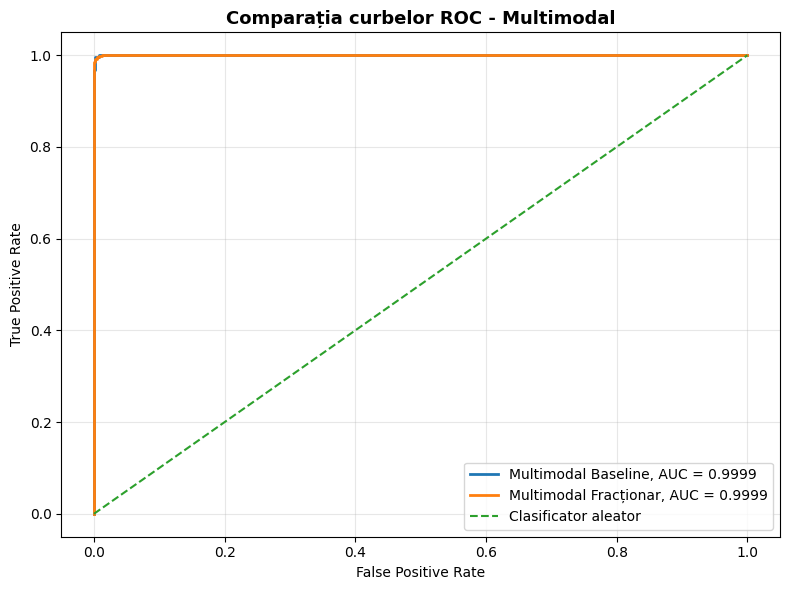

AUC Multimodal Baseline: 0.9999
AUC Multimodal Fracționar: 0.9999


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Etichete reale
y_true = np.argmax(test_y, axis=1)

# Predicții baseline
y_pred_probs_base = model_multimodal.predict([test_mri, test_ct], verbose=1)

# Predicții fracționar
y_pred_probs_frac = model_fractionar_multimodal.predict([test_mri, test_ct], verbose=1)

# Probabilitatea pentru clasa Tumor
y_score_base = y_pred_probs_base[:, 1]
y_score_frac = y_pred_probs_frac[:, 1]

# ROC + AUC
fpr_base, tpr_base, _ = roc_curve(y_true, y_score_base)
auc_base = auc(fpr_base, tpr_base)

fpr_frac, tpr_frac, _ = roc_curve(y_true, y_score_frac)
auc_frac = auc(fpr_frac, tpr_frac)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_base,
    tpr_base,
    linewidth=2,
    label=f"Multimodal Baseline, AUC = {auc_base:.4f}"
)

plt.plot(
    fpr_frac,
    tpr_frac,
    linewidth=2,
    label=f"Multimodal Fracționar, AUC = {auc_frac:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Clasificator aleator"
)

plt.title("Comparația curbelor ROC - Multimodal", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_multimodal.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC Multimodal Baseline: {auc_base:.4f}")
print(f"AUC Multimodal Fracționar: {auc_frac:.4f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison_nice(df):
    df = df.copy()

    # Dacă multimodalele există în memorie, completăm automat loss + accuracy
    if all(name in globals() for name in ["model_multimodal", "test_mri", "test_ct", "test_y"]):
        loss_base, acc_base = model_multimodal.evaluate(
            [test_mri, test_ct],
            test_y,
            verbose=0
        )

        if "multimodal_baseline" in df["model"].values:
            df.loc[df["model"] == "multimodal_baseline", "accuracy"] = acc_base
            df.loc[df["model"] == "multimodal_baseline", "loss"] = loss_base
        else:
            df = pd.concat([
                df,
                pd.DataFrame([{
                    "model": "multimodal_baseline",
                    "accuracy": acc_base,
                    "loss": loss_base
                }])
            ], ignore_index=True)

    if all(name in globals() for name in ["model_fractionar_multimodal", "test_mri", "test_ct", "test_y"]):
        loss_frac, acc_frac = model_fractionar_multimodal.evaluate(
            [test_mri, test_ct],
            test_y,
            verbose=0
        )

        if "multimodal_fractional" in df["model"].values:
            df.loc[df["model"] == "multimodal_fractional", "accuracy"] = acc_frac
            df.loc[df["model"] == "multimodal_fractional", "loss"] = loss_frac
        else:
            df = pd.concat([
                df,
                pd.DataFrame([{
                    "model": "multimodal_fractional",
                    "accuracy": acc_frac,
                    "loss": loss_frac
                }])
            ], ignore_index=True)

    # Eliminăm duplicatele, dacă există
    df = df.drop_duplicates(subset="model", keep="last")

    # 1. Nume mai frumoase
    name_map = {
        "mri_fractional": "MRI Fracționar",
        "mri_baseline": "MRI Baseline",
        "mri_fractional_rezidual": "MRI Fracționar Rezidual",
        "ct_baseline": "CT Baseline",
        "ct_fractional_rezidual": "CT Fracționar Rezidual",
        "multimodal_baseline": "Multimodal Baseline",
        "multimodal_fractional": "Multimodal Fracționar"
    }

    df["model_pretty"] = df["model"].map(name_map).fillna(df["model"])

    # 2. Categorie + culori
    def get_category(model_name):
        model_name = model_name.lower()
        if "multimodal" in model_name:
            return "Multimodal"
        elif "mri" in model_name:
            return "MRI"
        elif "ct" in model_name:
            return "CT"
        return "Altul"

    color_map = {
        "MRI": "#4C78A8",
        "CT": "#F58518",
        "Multimodal": "#54A24B",
        "Altul": "#9E9E9E"
    }

    df["categorie"] = df["model"].apply(get_category)
    df["culoare"] = df["categorie"].map(color_map)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_map["MRI"], label="MRI"),
        Patch(facecolor=color_map["CT"], label="CT"),
        Patch(facecolor=color_map["Multimodal"], label="Multimodal")
    ]

    # -------------------------
    # GRAFIC ACCURACY
    # -------------------------
    df_acc = df.sort_values("accuracy", ascending=True).reset_index(drop=True)

    plt.figure(figsize=(11.5, 6.5))

    bars = plt.barh(
        df_acc["model_pretty"],
        df_acc["accuracy"],
        color=df_acc["culoare"],
        height=0.6
    )

    min_acc = df_acc["accuracy"].min()
    max_acc = df_acc["accuracy"].max()

    left_lim = max(0.0, min_acc - 0.01)
    right_lim = min(1.01, max_acc + 0.01)
    plt.xlim(left_lim, right_lim)

    plt.title("Comparația performanței modelelor", fontsize=16, fontweight="bold")
    plt.xlabel("Acuratețe", fontsize=12)
    plt.ylabel("")
    plt.grid(axis="x", linestyle="--", alpha=0.35)

    for bar, value in zip(bars, df_acc["accuracy"]):
        label = f"{value * 100:.2f}%"
        y = bar.get_y() + bar.get_height() / 2

        if value > right_lim - 0.006:
            plt.text(
                value - 0.0015,
                y,
                label,
                va="center",
                ha="right",
                color="white",
                fontweight="bold",
                fontsize=11
            )
        else:
            plt.text(
                value + 0.001,
                y,
                label,
                va="center",
                ha="left",
                color="black",
                fontweight="bold",
                fontsize=11
            )

    plt.legend(handles=legend_elements, title="Categorie", loc="lower right")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # GRAFIC LOSS
    # -------------------------
    df_loss = df.dropna(subset=["loss"]).copy()

    if len(df_loss) > 0:
        df_loss = df_loss.sort_values("loss", ascending=True).reset_index(drop=True)

        plt.figure(figsize=(11.5, 6.5))

        bars = plt.barh(
            df_loss["model_pretty"],
            df_loss["loss"],
            color=df_loss["culoare"],
            height=0.6
        )

        max_loss = df_loss["loss"].max()
        right_lim = max_loss + max_loss * 0.15
        plt.xlim(0, right_lim)

        plt.title("Comparația erorii modelelor", fontsize=16, fontweight="bold")
        plt.xlabel("Loss / Eroare", fontsize=12)
        plt.ylabel("")
        plt.grid(axis="x", linestyle="--", alpha=0.35)

        for bar, value in zip(bars, df_loss["loss"]):
            label = f"{value:.4f}"
            y = bar.get_y() + bar.get_height() / 2

            if value > right_lim * 0.82:
                plt.text(
                    value - right_lim * 0.012,
                    y,
                    label,
                    va="center",
                    ha="right",
                    color="white",
                    fontweight="bold",
                    fontsize=11
                )
            else:
                plt.text(
                    value + right_lim * 0.01,
                    y,
                    label,
                    va="center",
                    ha="left",
                    color="black",
                    fontweight="bold",
                    fontsize=11
                )

        plt.legend(handles=legend_elements, title="Categorie", loc="lower right")
        plt.tight_layout()
        plt.show()

    return df

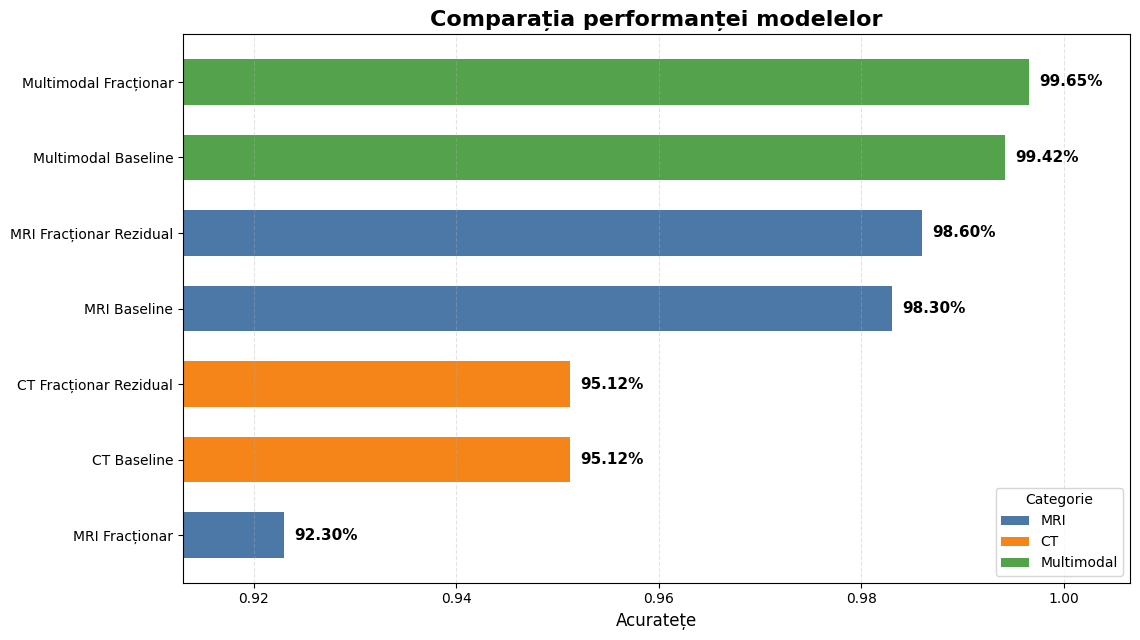

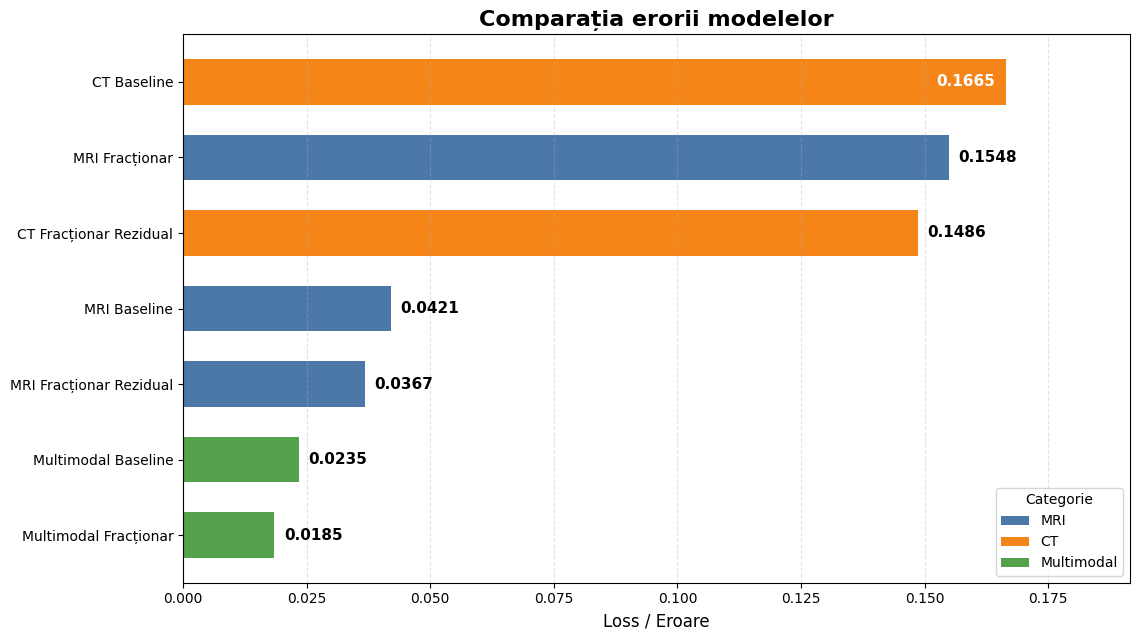

,model,accuracy,loss,model_pretty,categorie,culoare
1,mri_fractional,0.923000,0.154824,MRI Fracționar,MRI,#4C78A8
3,ct_baseline,0.951246,0.166542,CT Baseline,CT,#F58518
4,ct_fractional_rezidual,0.951246,0.148618,CT Fracționar Rezidual,CT,#F58518
0,mri_baseline,0.983000,0.042061,MRI Baseline,MRI,#4C78A8
2,mri_fractional_rezidual,0.986000,0.036741,MRI Fracționar Rezidual,MRI,#4C78A8
5,multimodal_baseline,0.994213,0.023457,Multimodal Baseline,Multimodal,#54A24B
6,multimodal_fractional,0.996528,0.018496,Multimodal Fracționar,Multimodal,#54A24B


In [ ]:
plot_model_comparison_nice(df_comparatie)